# Comparison of HCP group parcellations

This jupyter notebook is to demenstrate a comparison between different group parcellations generated from HCP dataset by different algorithm

In [1]:
import time
import numpy as np
# import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
# import HierarchBayesParcel.arrangements as ar
# import HierarchBayesParcel.emissions as em
# import HierarchBayesParcel.full_model as fm
# import FusionModel.util as futil
# import FusionModel.evaluate as ev

In [2]:
import os, sys 
sys.path.append(os.path.abspath('..'))

# from global_config import MODEL_DIR, BASE_DIR, ATLAS_DIR, DEVICE
# from scripts.group_parcellation import build_ukb_datasets, convert_hard_to_prob, get_indiv_parcellation_from_model
# from scripts.indiv_eval import *

## Evaluation

### 1. DCBC and Homogeneity on HCP 923 test subjects

### On a smaller subset of test subjects for quick check (N=73)

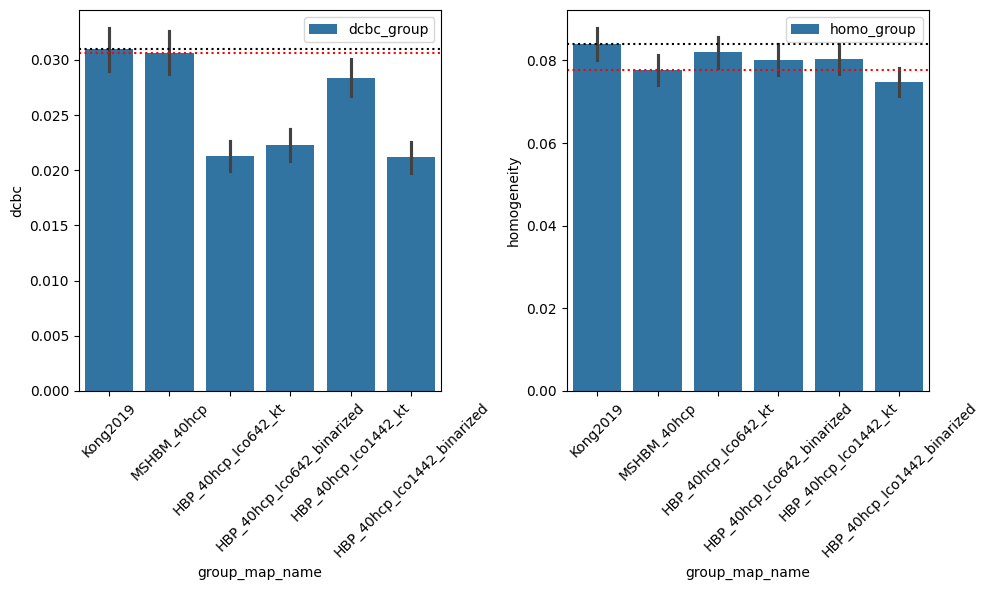

In [8]:
results = pd.DataFrame()

for i in [2]:
    for ses in ['ses-rest1', 'ses-rest2']:
        df = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_on-{ses}_split-test.tsv', sep='\t')
        results = pd.concat([results, df], ignore_index=True)

results = results[results.group_map_name != 'HBP_40hcp_Ico42-new']

baseline = results.loc[results.group_map_name == 'Kong2019']
to_compare = results.loc[results.group_map_name == 'MSHBM_40hcp']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')
plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')
plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

## Visual inspection

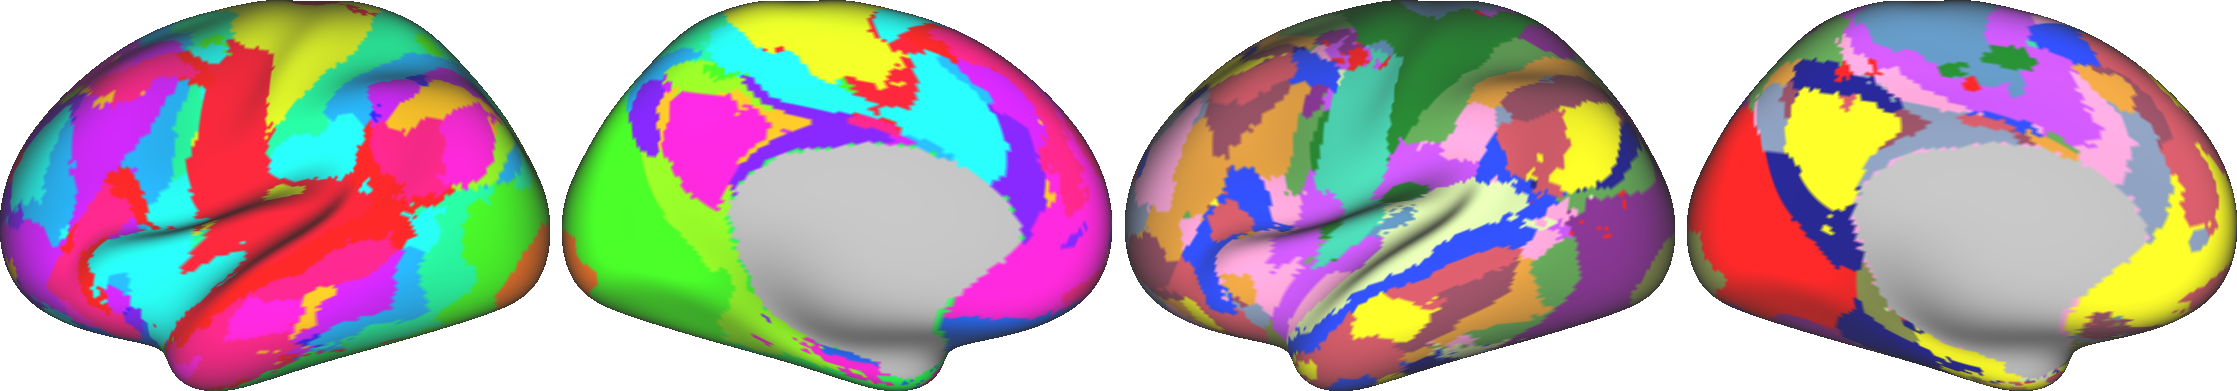

In [24]:
from IPython.display import Image, display, HTML

# Display the image with a caption
display(Image(filename='/PHShome/dz010/Documents/MSHBM_hcp40.png'))
display(HTML("<p style='text-align:center;'>MSHBM: trained on HCP 40 training set (ROI1483 + binarization top 10%)</p>"))

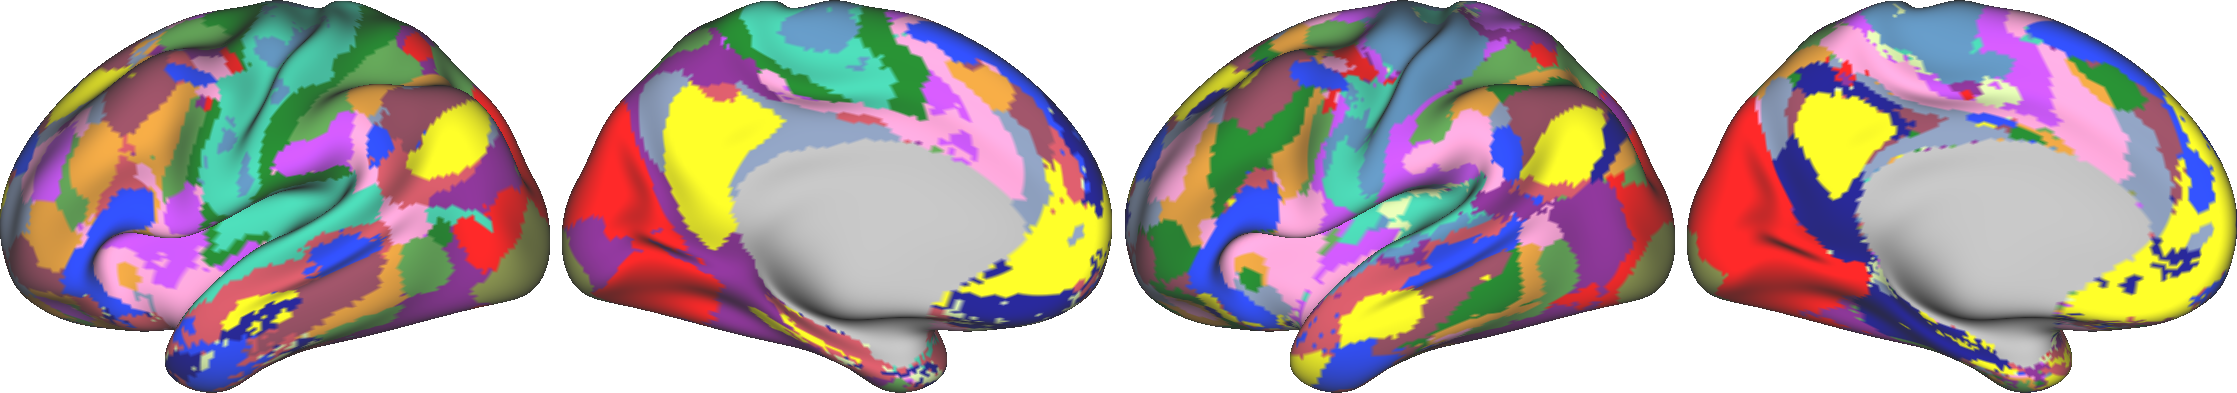

In [36]:
display(Image(filename='/PHShome/dz010/Documents/ICO42+ICA50.png'))
display(HTML("<p style='text-align:center;'>HBP: trained on HCP 40 training set (Left: Icosahedron 42, Right: ICA 50 networks, no binarization)</p>"))

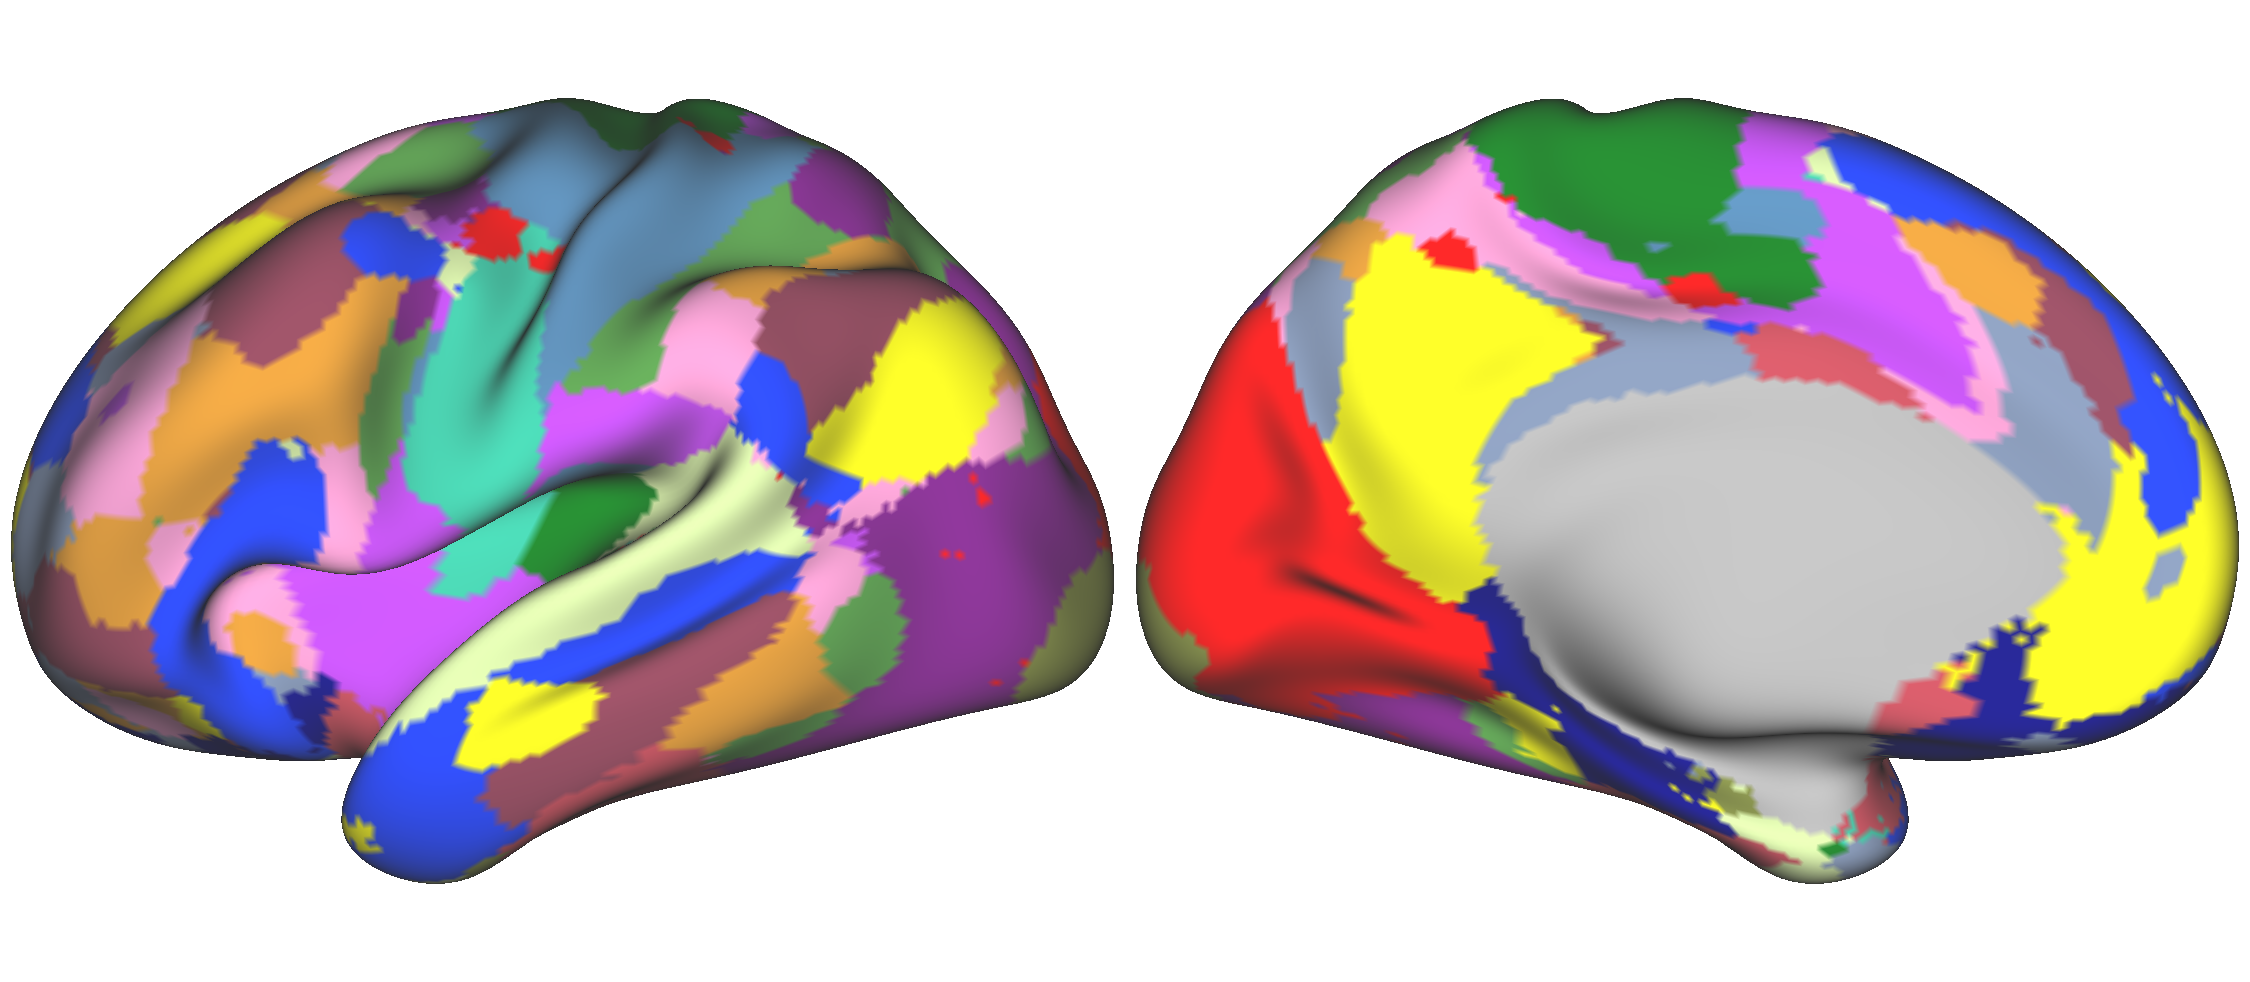

In [37]:
display(Image(filename='/PHShome/dz010/Documents/Ico1442.png', width=500))
display(HTML("<p style='text-align:center;'>HBP: trained on HCP 40 training set (Ico 1442 networks, binarization)</p>"))

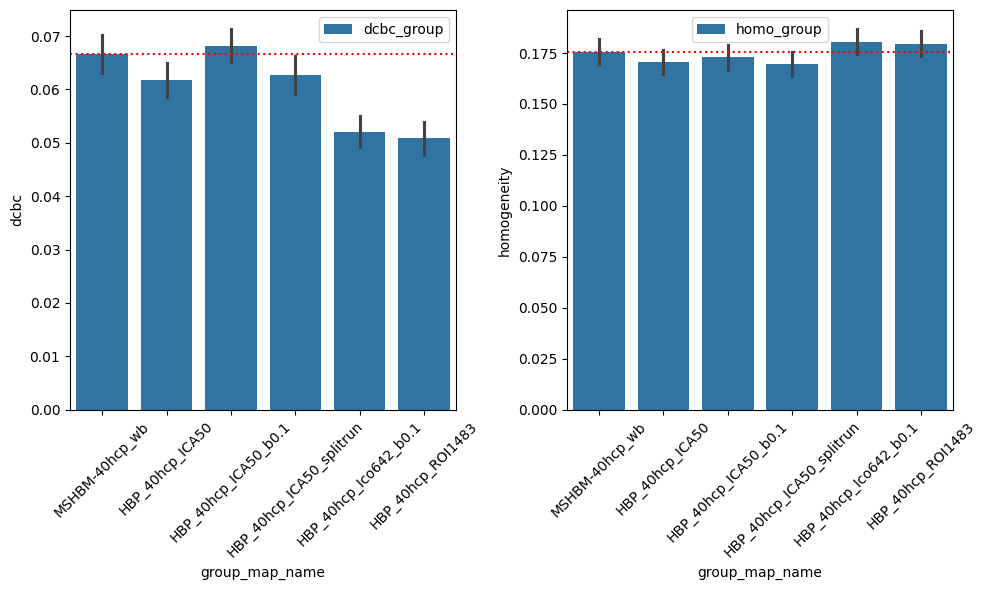

In [9]:
res_dir = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.DataFrame()

for i in [19]:
    for ses in ['ses-rest1', 'ses-rest2']:
        df = pd.read_csv(res_dir + f'/eval_MSHBM_vs_HBP_on-{ses}_sm-4fwhm_split-{i}.tsv', sep='\t')
        df_toadd = pd.read_csv(res_dir + f'/eval_MSHBM_vs_HBP_on-{ses}_sm-4fwhm_split-{i}_toadd.tsv', sep='\t')
        df_toadd2 = pd.read_csv(res_dir + f'/eval_MSHBM_vs_HBP_on-{ses}_sm-4fwhm_split-{i}_toaddroi1483.tsv', sep='\t')

        results = pd.concat([results, df, df_toadd], ignore_index=True)


baseline = results.loc[results.group_map_name == 'Kong2019']
to_compare = results.loc[results.group_map_name == 'MSHBM-40hcp_wb']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')
plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')
plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

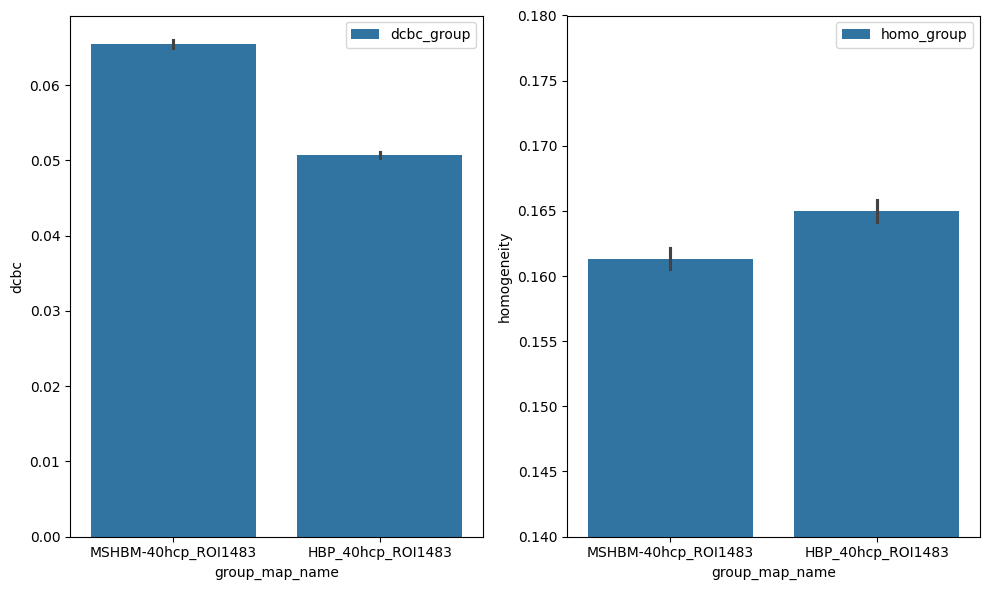

(923,)


TtestResult(statistic=-89.4688273211044, pvalue=0.0, df=922)

In [46]:
res_dir = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.read_csv(res_dir + f'/eval_MSHBM_vs_HBP_on-HCPtest_sm-4fwhm.tsv', sep='\t')

# baseline = results.loc[results.group_map_name == 'Kong2019']
# to_compare = results.loc[results.group_map_name == 'MSHBM-40hcp_wb']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')
# plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
# plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')
# plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.ylim(0.14, 0.18)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'MSHBM-40hcp_ROI1483']
b = results.loc[results.group_map_name == 'HBP_40hcp_ROI1483']

mshbm = a.groupby('subj_num')['homo_group'].mean()
hbp = b.groupby('subj_num')['homo_group'].mean()
print(mshbm.shape)
stats.ttest_rel(mshbm, hbp)

## Group evaluation on raw time series

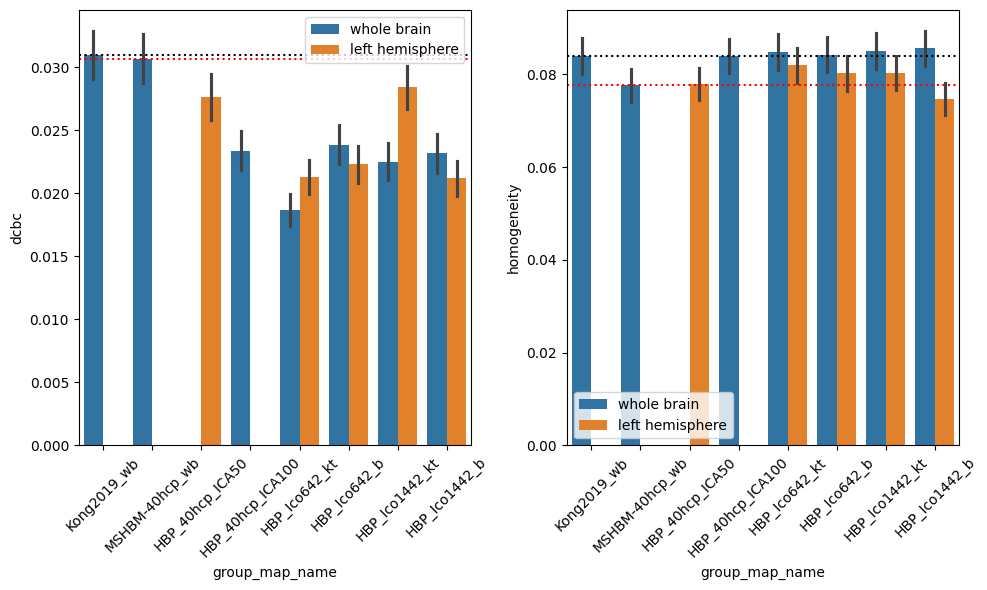

In [7]:
results = pd.DataFrame()

for i in [2]:
    for ses in ['ses-rest1', 'ses-rest2']:
        df = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_on-{ses}_split-test.tsv', sep='\t')
        results = pd.concat([results, df], ignore_index=True)

baseline = results.loc[results.group_map_name == 'Kong2019_wb']
to_compare = results.loc[results.group_map_name == 'MSHBM-40hcp_wb']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", hue='brain_wise', y='dcbc_group', errorbar="se")

plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", hue='brain_wise', y='homo_group', errorbar="se")
plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

## Group evaluation on smoothed time series (4fwhm) -  test set

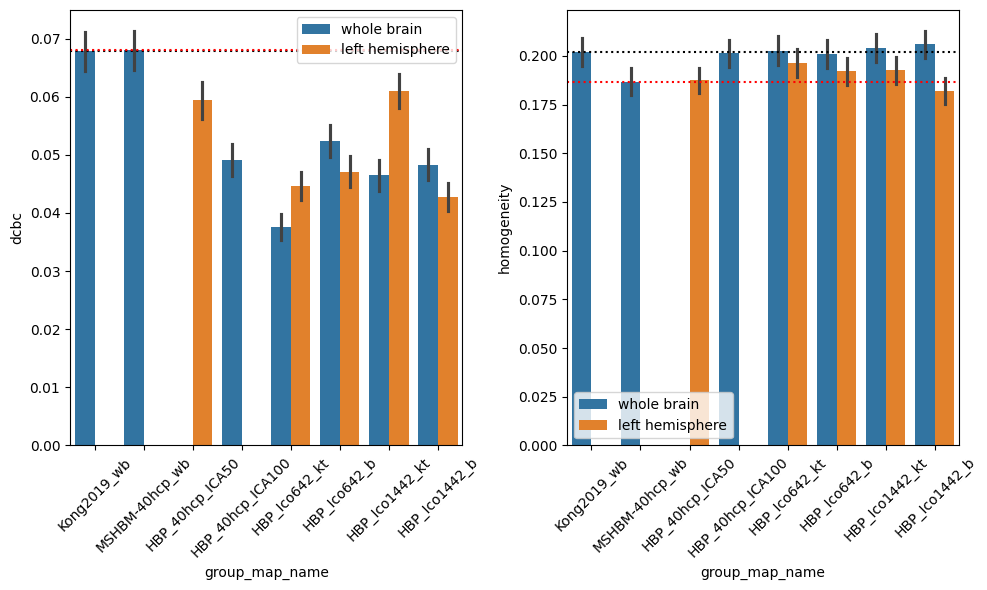

In [7]:
results = pd.DataFrame()

for i in [2]:
    for ses in ['ses-rest1', 'ses-rest2']:
        df = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_on-{ses}_sm-4fwhm_split-test.tsv', sep='\t')
        results = pd.concat([results, df], ignore_index=True)

baseline = results.loc[results.group_map_name == 'Kong2019_wb']
to_compare = results.loc[results.group_map_name == 'MSHBM-40hcp_wb']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", hue='brain_wise', y='dcbc_group', errorbar="se")

plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", hue='brain_wise', y='homo_group', errorbar="se")
plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

# Individual parcellatin and evaluation

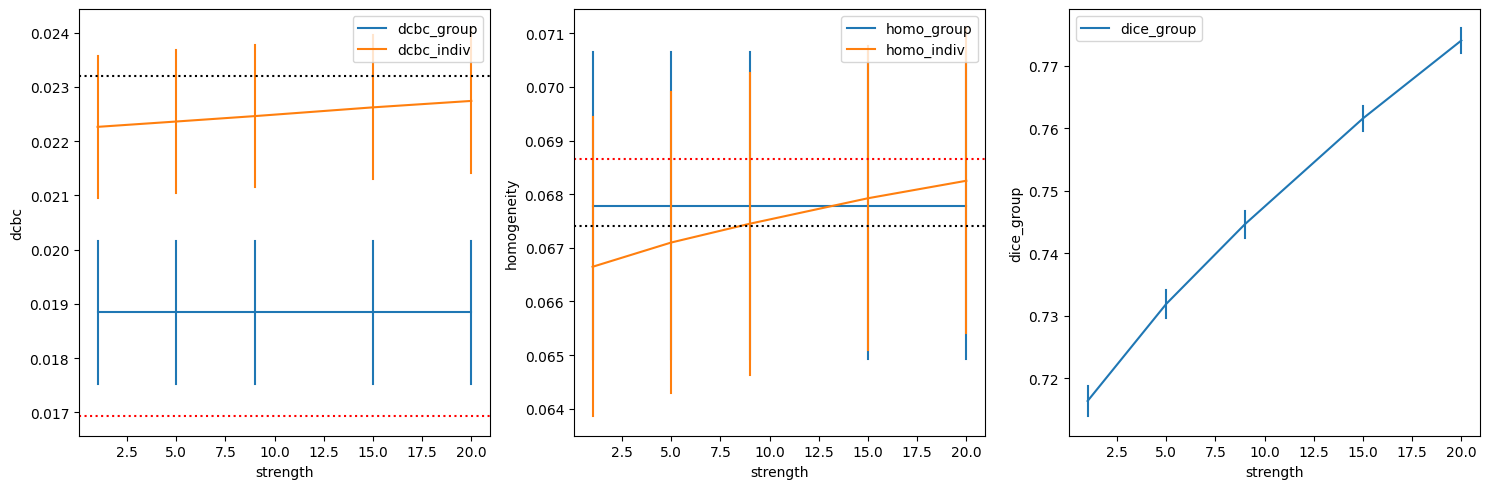

In [7]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40_on_HCP40validation_groupstrength-1to20.tsv', sep='\t')

kong_res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCP40_on_40validation_Tseries.tsv',
                      sep='\t')


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_group', errorbar="se",
            err_style="bars", markers=True, markersize=10, label='dcbc_group')
sb.lineplot(data=results, x="strength", y='dcbc_indiv', errorbar="se",
            err_style="bars", markers=True, markersize=10, label='dcbc_indiv')
plt.axhline(y=kong_res.dcbc_group.mean(), color='k', linestyle=':')
plt.axhline(y=kong_res.dcbc_indiv.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='homo_group', errorbar="se",
            err_style="bars", markers=True, markersize=10, label='homo_group')
sb.lineplot(data=results, x="strength", y='homo_indiv', errorbar="se",
            err_style="bars", markers=True, markersize=10, label='homo_indiv')
plt.axhline(y=kong_res.homo_group.mean(), color='k', linestyle=':')
plt.axhline(y=kong_res.homo_indiv.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', errorbar="se",
            err_style="bars", markers=True, markersize=10, label='dice_group')
plt.legend()

plt.tight_layout()
plt.savefig('/data/tge/dzhi/test.pdf', format='pdf')
plt.show()

# Grid search of parameters

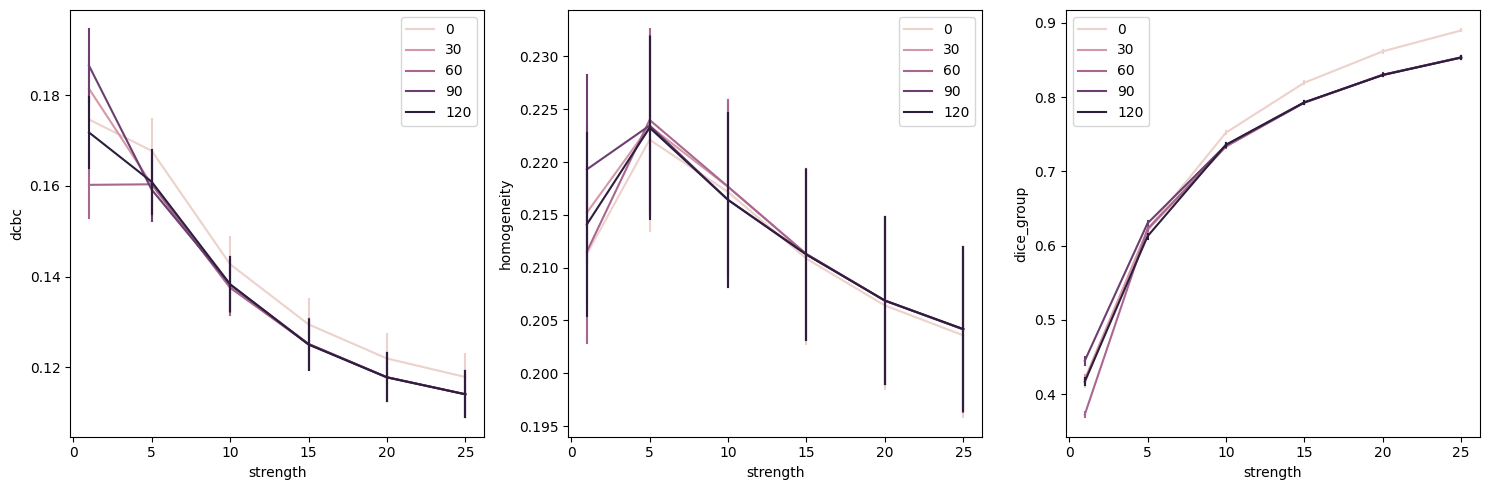

In [42]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_task_vs_rest_indiv_on-Md_prior-taskfusion.tsv', sep='\t')

kong_res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCP40_on_40validation_Tseries_desc-sm4fwhm.tsv',
                      sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
# sb.lineplot(data=results, x="strength", y='dcbc_group', errorbar="se",
#             err_style="bars", markers=True, markersize=10)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
# plt.axhline(y=kong_res.dcbc_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.dcbc_indiv.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
# sb.lineplot(data=results, x="strength", y='homo_group', errorbar="se",
#             err_style="bars", markers=True, markersize=10)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
# plt.axhline(y=kong_res.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.homo_indiv.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.savefig('/data/tge/dzhi/test.png', format='png')
plt.show()

# Individual parcellation on test set (first 50 subjects)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


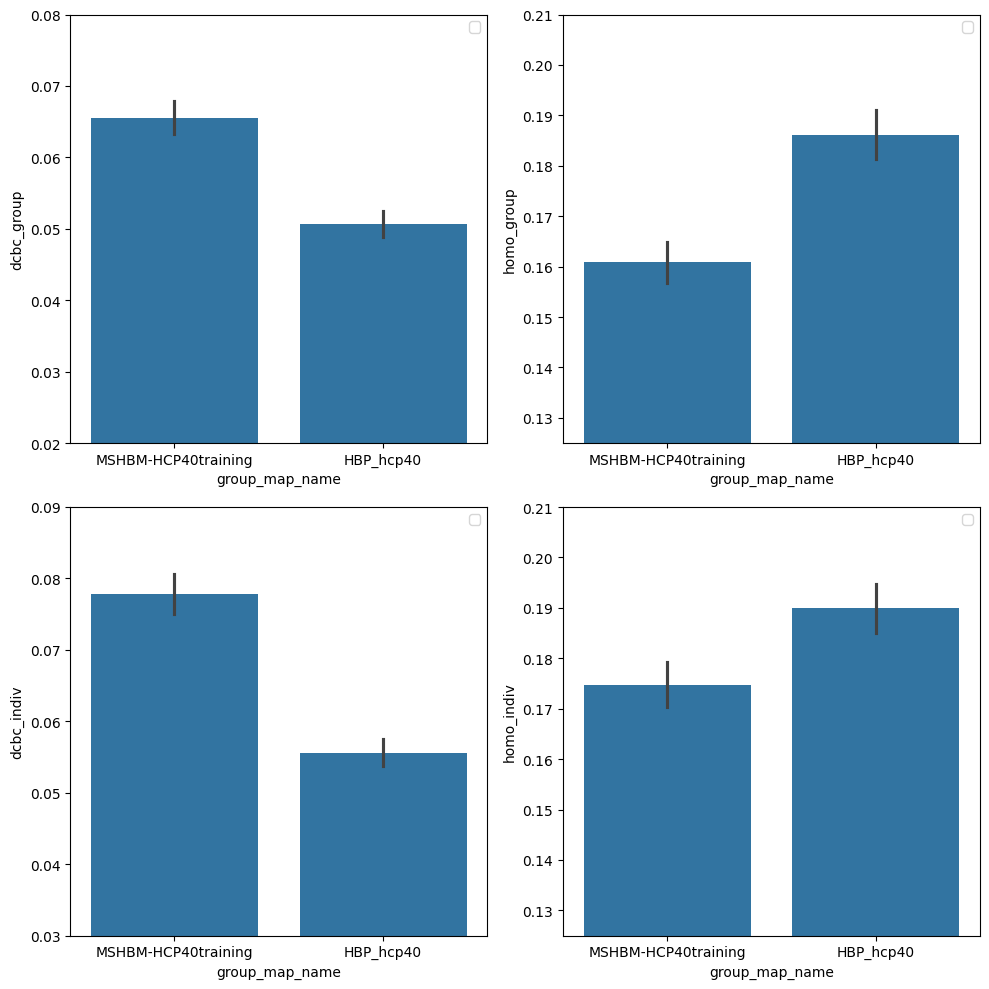

(150,)


TtestResult(statistic=-20.16225691751626, pvalue=2.0129216599828647e-44, df=149)

In [12]:
eval_dir = '/data/tge/dzhi/Indiv_par/Evaluations'

results1 = pd.read_csv(eval_dir + f'/eval_HCP923test_groupstrength-60_spatialW-90.tsv', sep='\t')
results1 = results1.replace("/Models_03/asym_Hc_space-fs32k_K-17_HCP40subjects_Ico642Run_desc-sm4fwhm_binarized", "HBP_hcp40")

# results1 = pd.read_csv(eval_dir + f'/eval_MSHBM_vs_HBP_indiv_on-HCPtest_sm-4fwhm_split-1.tsv', sep='\t')
results2 = pd.read_csv(eval_dir + f'/eval_MSHBM-HCP_test-indiv_on_50test_Tseries_desc-sm4fwhm.tsv',
                      sep='\t')
results = pd.concat([results2, results1], ignore_index=True)

plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se")
# plt.axhline(y=kong_res.dcbc_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.dcbc_indiv.mean(), color='r', linestyle=':')
plt.ylabel('dcbc_group')
plt.ylim(0.02,0.08)

plt.legend()

plt.subplot(2,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se")
# plt.axhline(y=kong_res.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.homo_indiv.mean(), color='r', linestyle=':')
plt.ylabel('homo_group')
plt.ylim(0.125,0.21)
plt.legend()

plt.subplot(2,2,3)
sb.barplot(data=results, x="group_map_name", y='dcbc_indiv', errorbar="se")
plt.ylabel('dcbc_indiv')
plt.ylim(0.03,0.09)
plt.legend()

plt.subplot(2,2,4)
sb.barplot(data=results, x="group_map_name", y='homo_indiv', errorbar="se")
# plt.axhline(y=kong_res.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.homo_indiv.mean(), color='r', linestyle=':')
plt.ylabel('homo_indiv')
plt.ylim(0.125,0.21)
plt.legend()

plt.tight_layout()
plt.savefig('/data/tge/dzhi/indiv_homo.pdf', format='pdf')
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'MSHBM-HCP40training']
b = results.loc[results.group_map_name == 'HBP_hcp40']

print(a.homo_indiv.shape)
stats.ttest_rel(a.homo_indiv, b.homo_indiv)

# Revisit group parcellation (test on 23 test subjects)

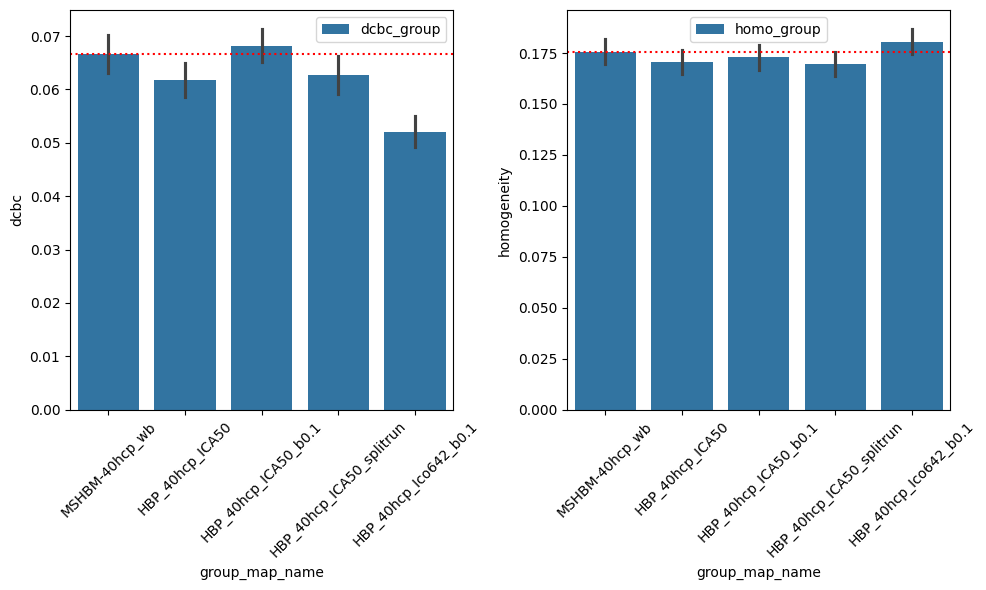

In [6]:
results = pd.DataFrame()

for i in [19]:
    for ses in ['ses-rest1', 'ses-rest2']:
        df = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_on-{ses}_sm-4fwhm_split-{i}.tsv', sep='\t')
        df_toadd = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_on-{ses}_sm-4fwhm_split-{i}_toadd.tsv', sep='\t')
        results = pd.concat([results, df, df_toadd], ignore_index=True)


baseline = results.loc[results.group_map_name == 'Kong2019']
to_compare = results.loc[results.group_map_name == 'MSHBM-40hcp_wb']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')
plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')
plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

## (Inhomogeneity - HCP task) Individual parcellation on test set (first 50 subjects)

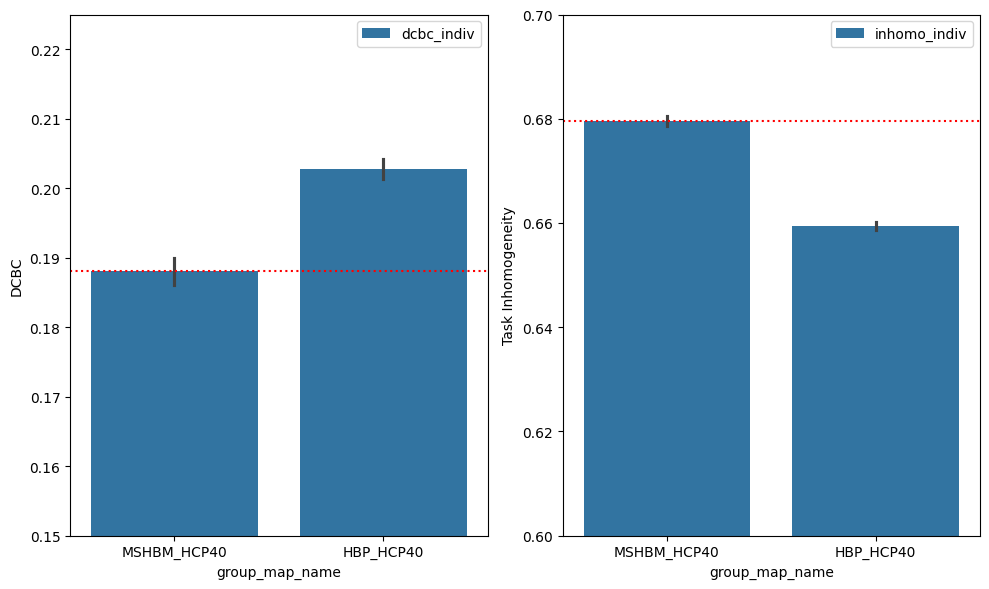

(50,)


TtestResult(statistic=18.981848489198455, pvalue=3.1309055772251493e-24, df=49)

In [6]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_indiv_teston-Task.tsv', sep='\t')

to_compare = results.loc[results.group_map_name == 'MSHBM_HCP40']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_indiv', errorbar="se", label='dcbc_indiv')
plt.axhline(y=to_compare.dcbc_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.15, 0.225)
plt.ylabel('DCBC')
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='inhomo_indiv', errorbar="se", label='inhomo_indiv')
plt.axhline(y=to_compare.inhomo_indiv.mean(), color='r', linestyle=':')

plt.ylabel('Task Inhomogeneity')
plt.ylim(0.6, 0.7)
plt.legend()
plt.tight_layout()
plt.savefig('/data/tge/dzhi/indiv_task_inhomo.pdf', format='pdf')
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'MSHBM_HCP40']
b = results.loc[results.group_map_name == 'HBP_HCP40']

print(a.inhomo_indiv.shape)
stats.ttest_rel(a.inhomo_indiv, b.inhomo_indiv)

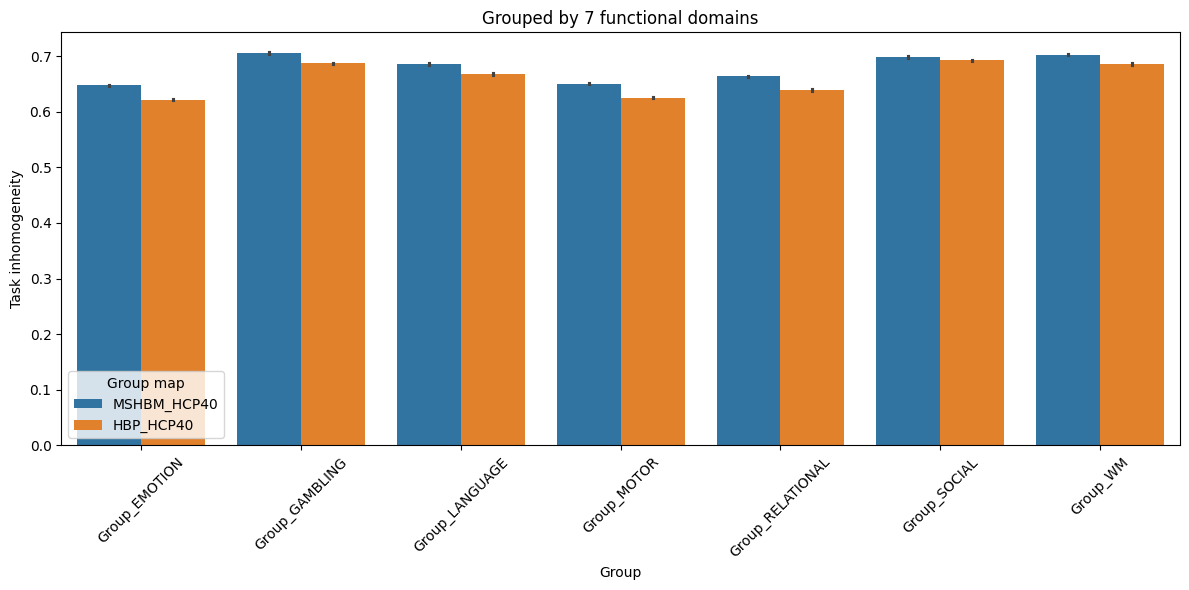

In [33]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_indiv_teston-Task_separate_test.tsv', sep='\t')

contrast_file = '/data/tge/Tian/HCP_img' + '/rfMRI/fix_32k/group/' + \
                    'HCP_S1200_997_tfMRI_ALLTASKS_level2_cohensd_hp200_s2_MSMAll.dscalar.nii'
task_name = np.array(nb.load(contrast_file).header.get_axis(0).name, dtype=object)

group_vector = [s.split('_')[1] for s in task_name]

cond_names = [f'inhomo_indiv_{i}' for i in task_name]
grouped_data = pd.DataFrame({'group_map_name': results['group_map_name']})

# Group the conditions based on the group vector
for group in np.unique(group_vector):
    group_conditions = [cond_names[i] for i in range(len(group_vector)) if group_vector[i] == group]
    grouped_data[f'Group_{group}'] = results[group_conditions].mean(axis=1)

df_grouped_melted = pd.melt(grouped_data, id_vars='group_map_name',
                            value_vars=[f'Group_{s}' for s in np.unique(group_vector)],
                            var_name='Group', value_name='Mean')

# Plot the bar plot
plt.figure(figsize=(12, 6))
sb.barplot(x='Group', y='Mean', hue='group_map_name', data=df_grouped_melted, errorbar='se', dodge=True)

# Customize the plot
plt.title('Grouped by 7 functional domains')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Group map')

plt.ylabel('Task inhomogeneity')

# Show the plot
plt.tight_layout()
plt.show()

# Reproducibility test - Individual parcellations (HCP test)

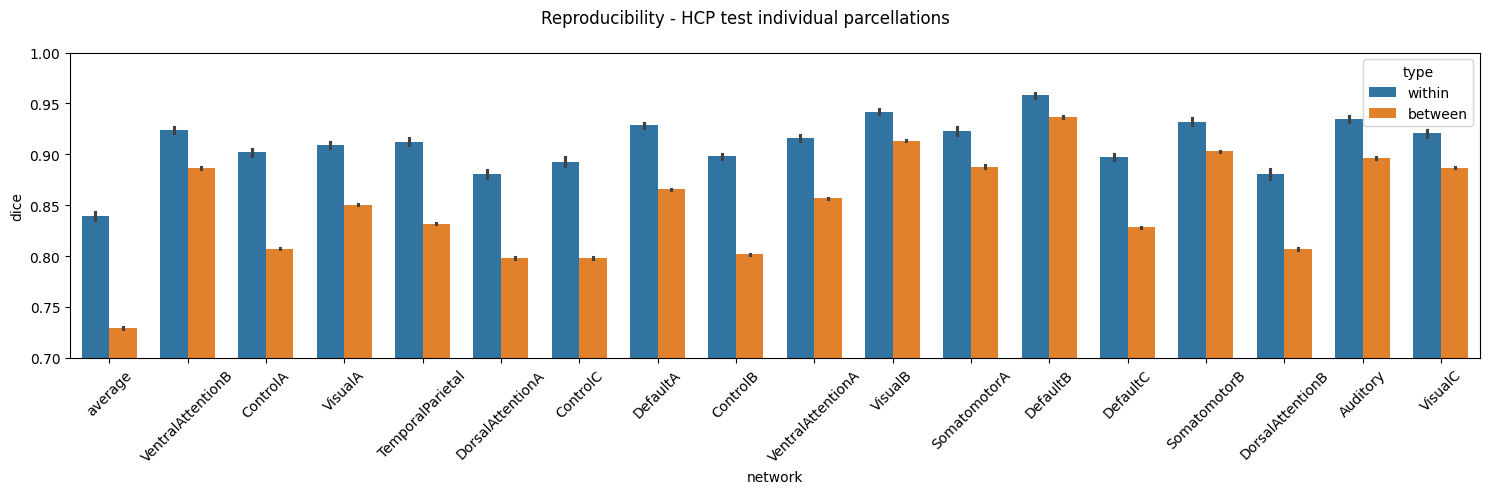

In [5]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.read_csv(RES_DIR + f'/reproducibility_MSHBM_vs_HBP_indiv_HCPtest.tsv', sep='\t')

# Plot results
plt.figure(figsize=(15, 5))
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='network', y='dice', hue='type', 
           errorbar='se', width=0.7)

plt.xticks(rotation=45)
plt.ylim(0.7, 1)
plt.suptitle('Reproducibility - HCP test individual parcellations')
plt.tight_layout()
plt.show()

# Group parcellation evaluation: Resting + Task, resting only

## 1. HCP40 vs. HCP 40 + MDTB24

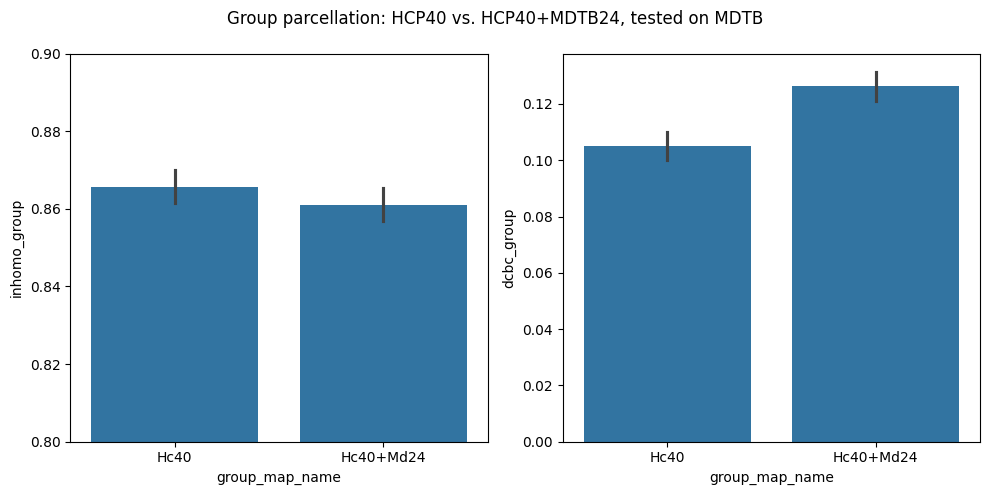

In [7]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdHc_on-Md.tsv', sep='\t')
res = res.replace(['HBP_Hc40_ROI642Run', 'HBP_Hc40-ROI642Run_Md24-CondHalf'],
                   ['Hc40', 'Hc40+Md24'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='inhomo_group', errorbar='se')
plt.ylim(0.8, 0.9)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP40 vs. HCP40+MDTB24, tested on MDTB')
plt.tight_layout()
plt.show()

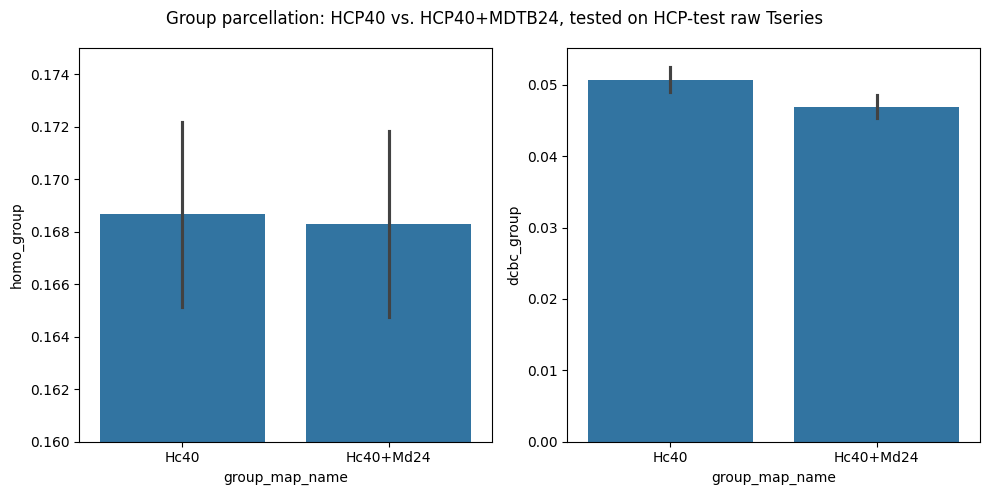

In [11]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdHc_on-Hc-test.tsv', sep='\t')
res = res.replace(['HBP_Hc40_ROI642Run', 'HBP_Hc40-ROI642Run_Md24-CondHalf'],
                   ['Hc40', 'Hc40+Md24'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.16, 0.175)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP40 vs. HCP40+MDTB24, tested on HCP-test raw Tseries')
plt.tight_layout()
plt.show()

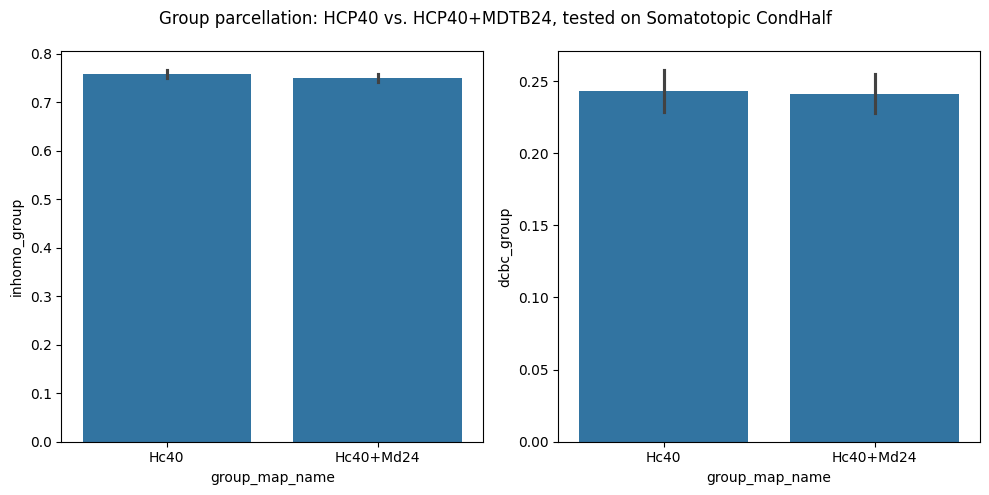

In [14]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdHc_on-Wm-CondHalf.tsv', sep='\t')
res = res.replace(['HBP_Hc40_ROI642Run', 'HBP_Hc40-ROI642Run_Md24-CondHalf'],
                   ['Hc40', 'Hc40+Md24'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='inhomo_group', errorbar='se')

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP40 vs. HCP40+MDTB24, tested on Somatotopic CondHalf')
plt.tight_layout()
plt.show()

## 1. HCP40 vs. HCP 40 + WMFS 16

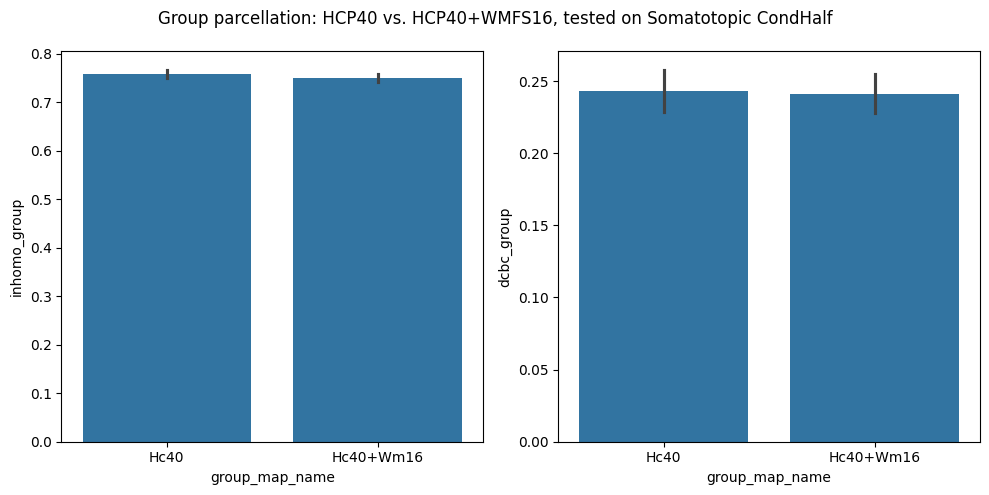

In [15]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_WmHc_on-So-CondHalf.tsv', sep='\t')
res = res.replace(['HBP_Hc40_ROI642Run', 'HBP_Hc40-ROI642Run_Wm16-CondHalf'],
                   ['Hc40', 'Hc40+Wm16'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='inhomo_group', errorbar='se')

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP40 vs. HCP40+WMFS16, tested on Somatotopic CondHalf')
plt.tight_layout()
plt.show()

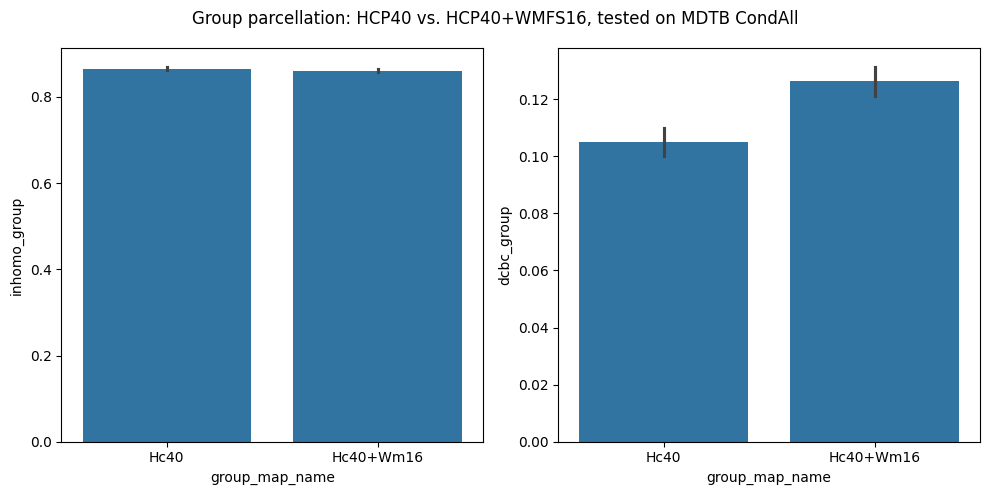

In [16]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_WmHc_on-Md-CondAll.tsv', sep='\t')
res = res.replace(['HBP_Hc40_ROI642Run', 'HBP_Hc40-ROI642Run_Wm16-CondHalf'],
                   ['Hc40', 'Hc40+Wm16'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='inhomo_group', errorbar='se')

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP40 vs. HCP40+WMFS16, tested on MDTB CondAll')
plt.tight_layout()
plt.show()

## Group parcellation by different amount of subjects

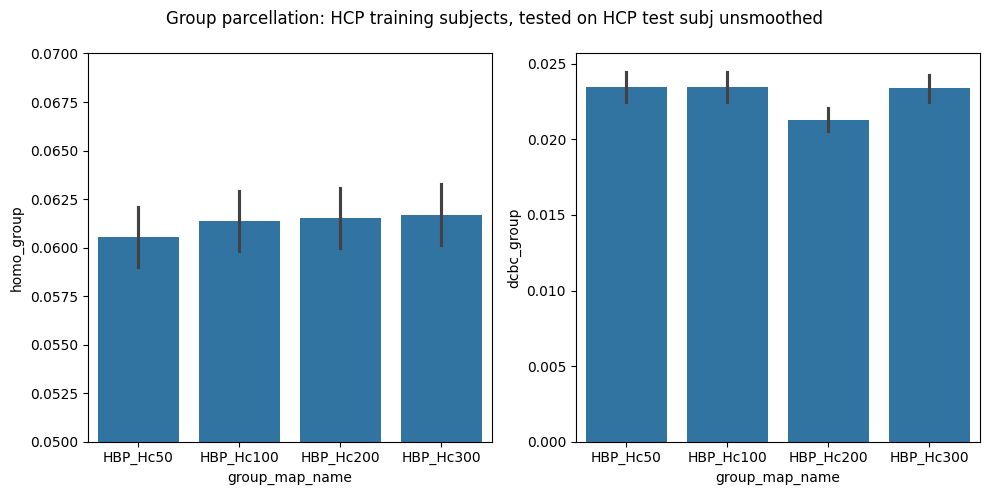

In [3]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HBP-Hc50to300_on-HCPtest.tsv', sep='\t')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.05, 0.07)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Task group parcellation by different K (test on HCP 203)

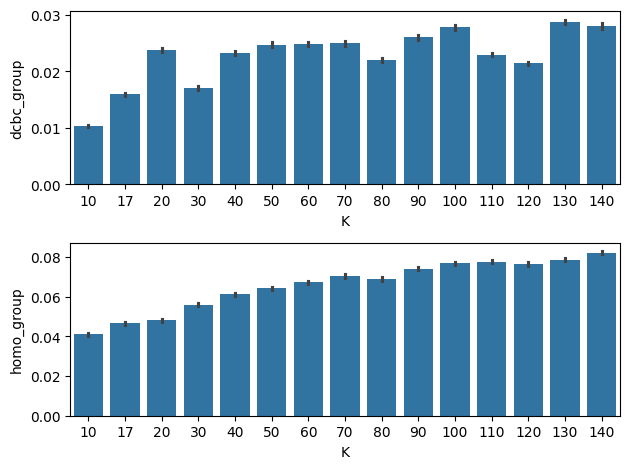

In [13]:
result = pd.DataFrame()

for k in [10,17,20]:
    for i in [1,2,3,4,5]:
        res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdPoNiWmDeSo_K-{k}_on-HCPtest_split-{i}.tsv', sep='\t')
        result = pd.concat([result, res], ignore_index=True)

for k in [30,40,50,60,70,80,90,100,110,120,130,140]:
    for i in [1,2,3,4]:
        res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdPoNiWmDeSo_K-{k}_on-HCPtest_split-{i}.tsv', sep='\t')
        result = pd.concat([result, res], ignore_index=True)
        
plt.subplot(2,1,1)
sb.barplot(data=result, x='K', y='dcbc_group', errorbar='se')

plt.subplot(2,1,2)
sb.barplot(data=result, x='K', y='homo_group', errorbar='se')

plt.tight_layout()
plt.show()

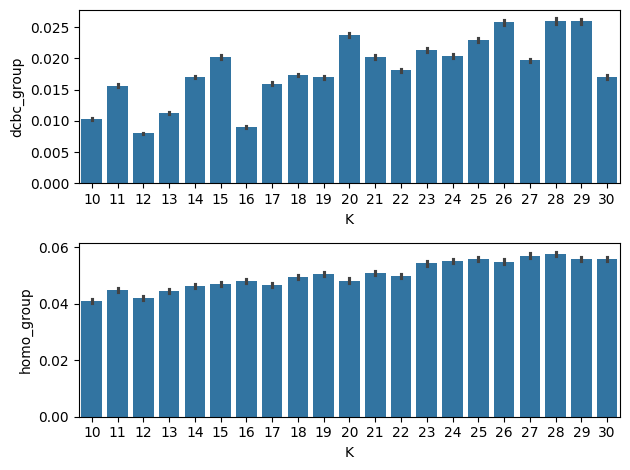

In [14]:
result = pd.DataFrame()

for k in range(10,31):
    for i in [1,2,3,4]:
        res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdPoNiWmDeSo_K-{k}_on-HCPtest_split-{i}.tsv', sep='\t')
        result = pd.concat([result, res], ignore_index=True)
        
plt.subplot(2,1,1)
sb.barplot(data=result, x='K', y='dcbc_group', errorbar='se')

plt.subplot(2,1,2)
sb.barplot(data=result, x='K', y='homo_group', errorbar='se')

plt.tight_layout()
plt.show()

## Compare mask and smooth

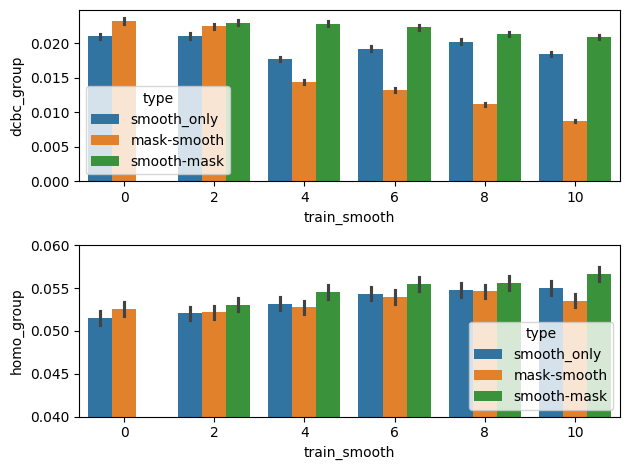

In [5]:
smooth_only = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_Md_K-17_sm0-10_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res.group_map_name.replace(['Md_K-17_','Md_K-17__sm2fwhm','Md_K-17__sm4fwhm',
                               'Md_K-17__sm6fwhm','Md_K-17__sm8fwhm','Md_K-17__sm10fwhm'], [0,2,4,6,8,10])
    res['subj_num'] += (i-1)*50
    res['type'] = 'smooth_only'
    smooth_only = pd.concat([smooth_only, res], ignore_index=True)

smooth_mask = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_Md_K-17_sm0-10_masked_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res.group_map_name.replace(['Md_K-17_sm2fwhm_masked','Md_K-17_sm4fwhm_masked',
                                                      'Md_K-17_sm6fwhm_masked','Md_K-17_sm8fwhm_masked',
                                                      'Md_K-17_sm10fwhm_masked'], [2,4,6,8,10])
    res['subj_num'] += (i-1)*50
    res['type'] = 'smooth-mask'
    smooth_mask = pd.concat([smooth_mask, res], ignore_index=True)
    
mask_smooth = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_Md_K-17_masked_sm0-10_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res.group_map_name.replace(['Md_K-17','Md_K-17_desc-sm2fwhm','Md_K-17_desc-sm4fwhm',
                               'Md_K-17_desc-sm6fwhm','Md_K-17_desc-sm8fwhm','Md_K-17_desc-sm10fwhm'], [0,2,4,6,8,10])
    res['subj_num'] += (i-1)*50
    res['type'] = 'mask-smooth'
    mask_smooth = pd.concat([mask_smooth, res], ignore_index=True)
    
result = pd.concat([smooth_only, smooth_mask, mask_smooth], ignore_index=True)
plt.subplot(2,1,1)
sb.barplot(data=result, x='train_smooth', y='dcbc_group', hue='type',errorbar='se')

plt.subplot(2,1,2)
sb.barplot(data=result, x='train_smooth', y='homo_group', hue='type',errorbar='se')
plt.ylim(0.04,0.06)

plt.tight_layout()
plt.show()

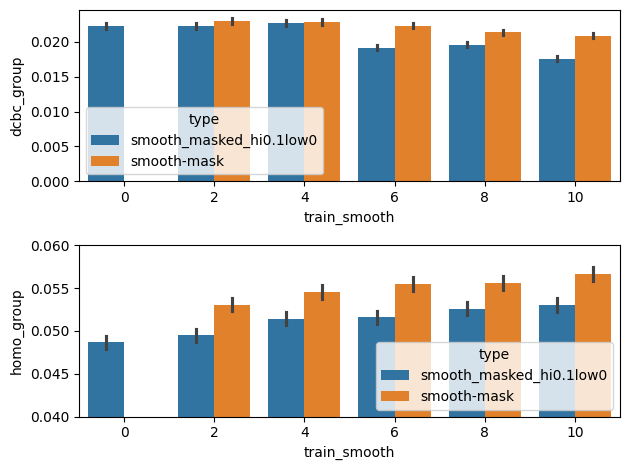

In [6]:
smooth_mask_high = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_Md_K-17_sm0-10_masked-hi10lo0_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res.group_map_name.replace(['Md_K-17__masked','Md_K-17__sm2fwhm_masked','Md_K-17__sm4fwhm_masked',
                               'Md_K-17__sm6fwhm_masked','Md_K-17__sm8fwhm_masked','Md_K-17__sm10fwhm_masked'], [0,2,4,6,8,10])
    res['subj_num'] += (i-1)*50
    res['type'] = 'smooth_masked_hi0.1low0'
    smooth_mask_high = pd.concat([smooth_mask_high, res], ignore_index=True)

smooth_mask = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_Md_K-17_sm0-10_masked_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res.group_map_name.replace(['Md_K-17_sm2fwhm_masked','Md_K-17_sm4fwhm_masked',
                                                      'Md_K-17_sm6fwhm_masked','Md_K-17_sm8fwhm_masked',
                                                      'Md_K-17_sm10fwhm_masked'], [2,4,6,8,10])
    res['subj_num'] += (i-1)*50
    res['type'] = 'smooth-mask'
    smooth_mask = pd.concat([smooth_mask, res], ignore_index=True)

    
result = pd.concat([smooth_mask_high, smooth_mask], ignore_index=True)
plt.subplot(2,1,1)
sb.barplot(data=result, x='train_smooth', y='dcbc_group', hue='type',errorbar='se')

plt.subplot(2,1,2)
sb.barplot(data=result, x='train_smooth', y='homo_group', hue='type',errorbar='se')
plt.ylim(0.04,0.06)

plt.tight_layout()
plt.show()

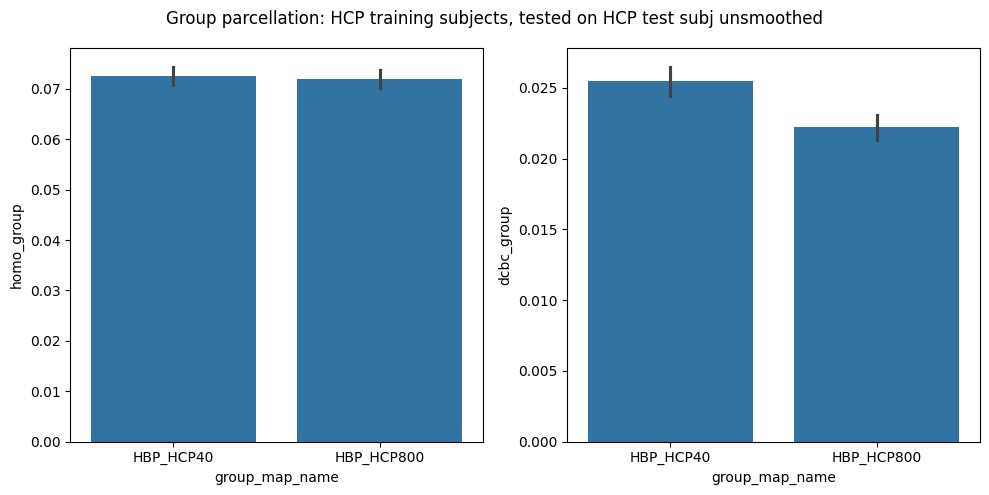

In [9]:
result = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800_K-17_on-HCPtest_split-{i}.tsv', sep='\t')
    result = pd.concat([result, res], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()


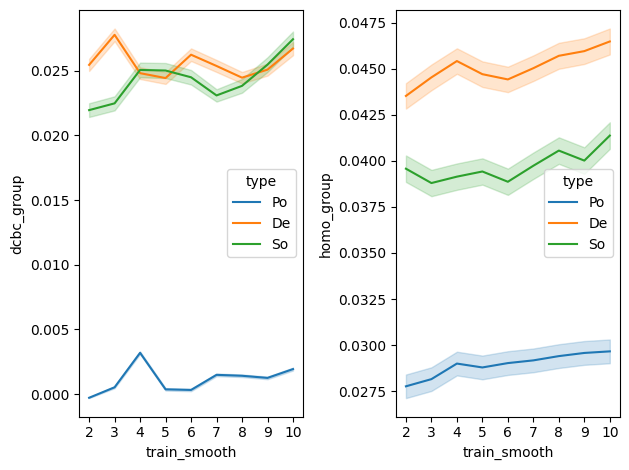

In [11]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_PoDeSo_K-17_smooth-masked_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res['group_map_name'].str.extract(r'(?:\D*\d+\D+)*?(\d+)')
    res['subj_num'] += (i-1)*50
    res['type'] = res['group_map_name'].str[:2]
    results = pd.concat([results, res], ignore_index=True)

plt.subplot(1,2,1)
sb.lineplot(data=results, x='train_smooth', y='dcbc_group', hue='type',errorbar='se')

plt.subplot(1,2,2)
sb.lineplot(data=results, x='train_smooth', y='homo_group', hue='type',errorbar='se')

plt.tight_layout()
plt.show()

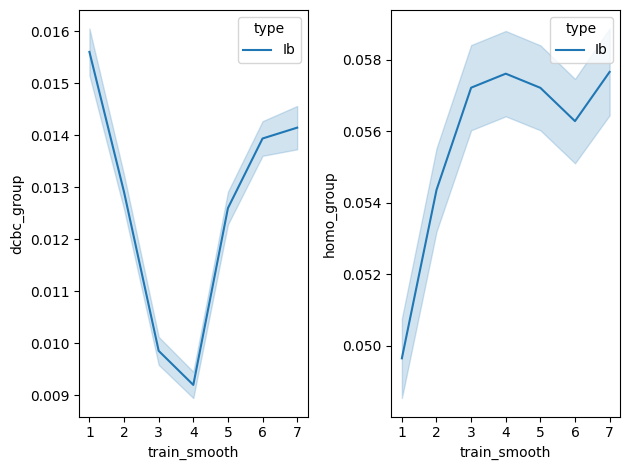

In [12]:
results = pd.DataFrame()
for i in [1,2]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_Ib_K-17_smooth-masked_on-HCPtest_split-{i}.tsv', sep='\t')
    res['train_smooth'] = res['group_map_name'].str.extract(r'(?:\D*\d+\D+)*?(\d+)')
    res['subj_num'] += (i-1)*50
    res['type'] = res['group_map_name'].str[:2]
    results = pd.concat([results, res], ignore_index=True)

plt.subplot(1,2,1)
sb.lineplot(data=results, x='train_smooth', y='dcbc_group', hue='type',errorbar='se')

plt.subplot(1,2,2)
sb.lineplot(data=results, x='train_smooth', y='homo_group', hue='type',errorbar='se')

plt.tight_layout()
plt.show()

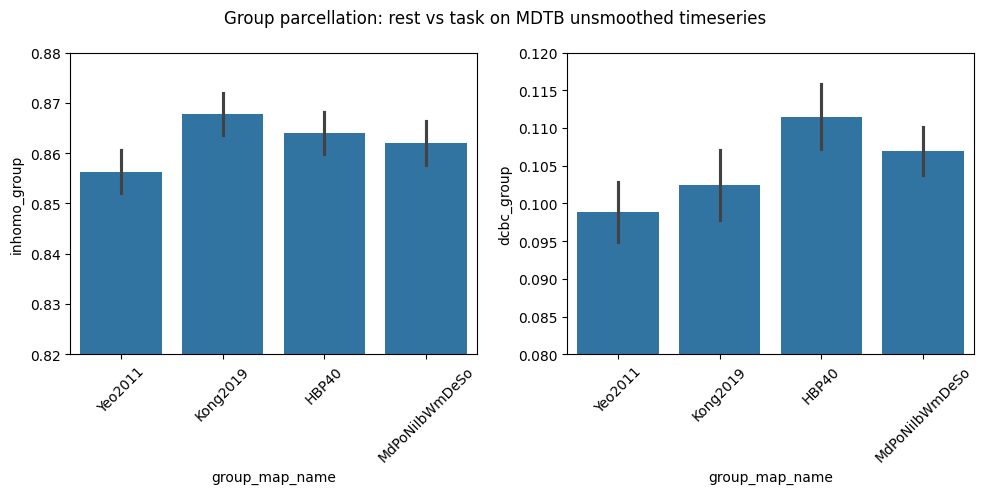

In [21]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_rest_vs_task-fusion_on-Md-CondAll.tsv', sep='\t')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='inhomo_group', errorbar='se')
plt.xticks(rotation=45)
plt.ylim(0.82, 0.88)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)
plt.ylim(0.08, 0.12)

plt.suptitle('Group parcellation: rest vs task on MDTB unsmoothed timeseries')
plt.tight_layout()
plt.show()

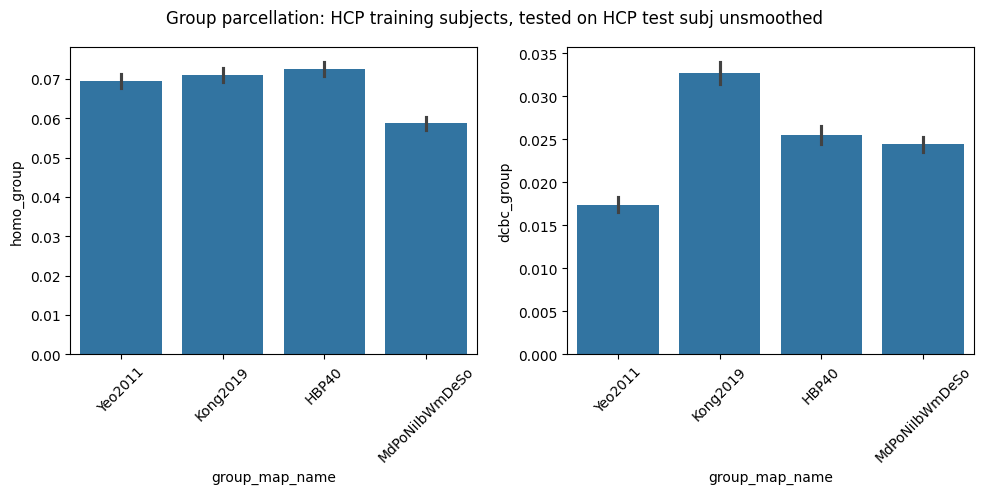

In [25]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_rest_vs_task-fusion_on-HCPtest_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

['GoNoGo' 'ToM' 'actionObservation' 'affective' 'arithmetic'
 'checkerBoard' 'emotional' 'intervalTiming' 'motorImagery'
 'motorSequence' 'nBack' 'nBackPic' 'spatialNavigation' 'stroop'
 'verbGeneration' 'visualSearch' 'rest' 'CPRO' 'prediction' 'spatialMap'
 'natureMovie' 'romanceMovie' 'landscapeMovie' 'mentalRotation'
 'emotionProcess' 'respAlt']


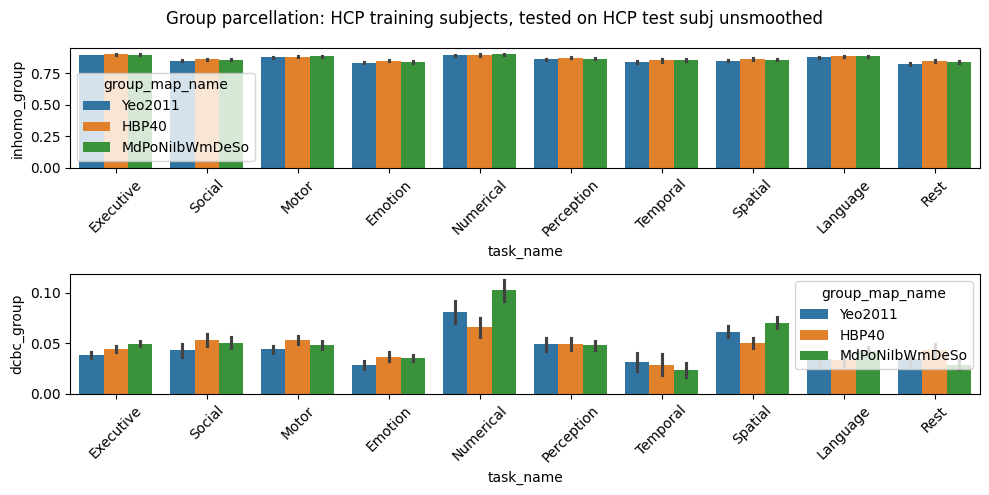

In [41]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP_vs_PoNiIbWmDeSo_on-Md-CondHalf-tasks.tsv', sep='\t')

print(res.task_name.unique())
res = res.replace(res.task_name.unique(), ['Executive', 'Social', 'Motor', 'Emotion', 'Numerical', 'Perception',
                                          'Emotion', 'Temporal', 'Motor', 'Motor', 'Executive', 'Executive', 'Spatial',
                                          'Executive', 'Language', 'Perception', 'Rest', 'Executive', 'Executive',
                                          'Spatial', 'Social', 'Social', 'Perception', 'Spatial', 'Emotion', 'Motor'])

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
sb.barplot(data=res, x='task_name', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=res, x='task_name', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

(48, 20)


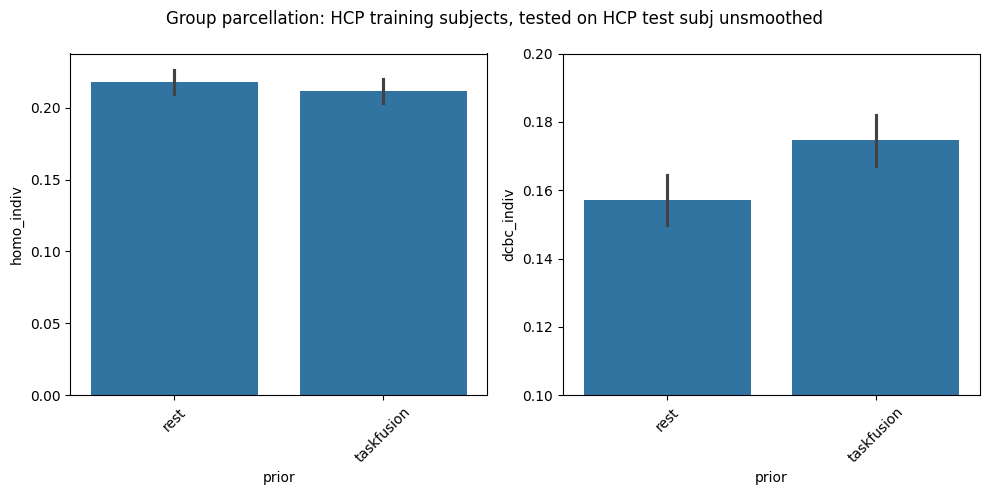

(24,)


TtestResult(statistic=-7.374475734885242, pvalue=1.6839114846586404e-07, df=23)

In [58]:
res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_task_vs_rest_indiv_on-Md.tsv', sep='\t')
res2 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_task_vs_rest_indiv_on-Md_prior-taskfusion.tsv', sep='\t')
res1 = res1.loc[(res1["strength"]==1) & (res1['spatial_w']==0)]
res1['prior'] = 'rest'
res2['prior'] = 'taskfusion'

res2 = res2.loc[(res2["strength"]==1) & (res2['spatial_w']==0)]
results = pd.concat([res1, res2], ignore_index=True)
print(results.shape)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='prior', y='homo_indiv', errorbar='se')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='prior', y='dcbc_indiv', errorbar='se')
plt.xticks(rotation=45)
plt.ylim(0.1,0.2)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.savefig('/data/tge/dzhi/fig2_indiv.pdf', format='pdf')

plt.show()

from scipy import stats
a = results.loc[results.prior == 'rest']
b = results.loc[results.prior == 'taskfusion']

print(a.dcbc_indiv.shape)
stats.ttest_rel(a.dcbc_indiv, b.dcbc_indiv)


['GoNoGo' 'ToM' 'actionObservation' 'affective' 'arithmetic'
 'checkerBoard' 'emotional' 'intervalTiming' 'motorImagery'
 'motorSequence' 'nBack' 'nBackPic' 'spatialNavigation' 'stroop'
 'verbGeneration' 'visualSearch' 'rest' 'CPRO' 'prediction' 'spatialMap'
 'natureMovie' 'romanceMovie' 'landscapeMovie' 'mentalRotation'
 'emotionProcess' 'respAlt']


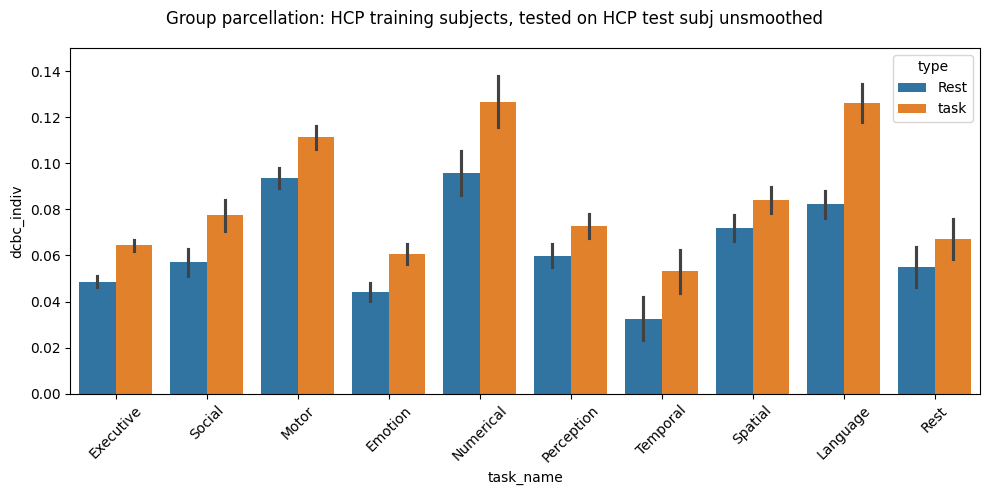

In [10]:
res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_rest_indiv_on-Md_prior-rest_tasks.tsv', sep='\t')
res1['type']='rest'
res2 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_task_indiv_on-Md_prior-taskfusion_tasks.tsv', sep='\t')
res2['type']='task'
res = pd.concat([res1, res2], ignore_index=True)

print(res.task_name.unique())
res = res.replace(res.task_name.unique(), ['Executive', 'Social', 'Motor', 'Emotion', 'Numerical', 'Perception',
                                          'Emotion', 'Temporal', 'Motor', 'Motor', 'Executive', 'Executive', 'Spatial',
                                          'Executive', 'Language', 'Perception', 'Rest', 'Executive', 'Executive',
                                          'Spatial', 'Social', 'Social', 'Perception', 'Spatial', 'Emotion', 'Motor'])

plt.figure(figsize=(10,5))
sb.barplot(data=res, x='task_name', y='dcbc_indiv', hue='type', errorbar='se')
plt.xticks(rotation=45)
plt.ylim(0,0.15)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.savefig('/data/tge/dzhi/fig2_indiv2.pdf', format='pdf')
plt.show()

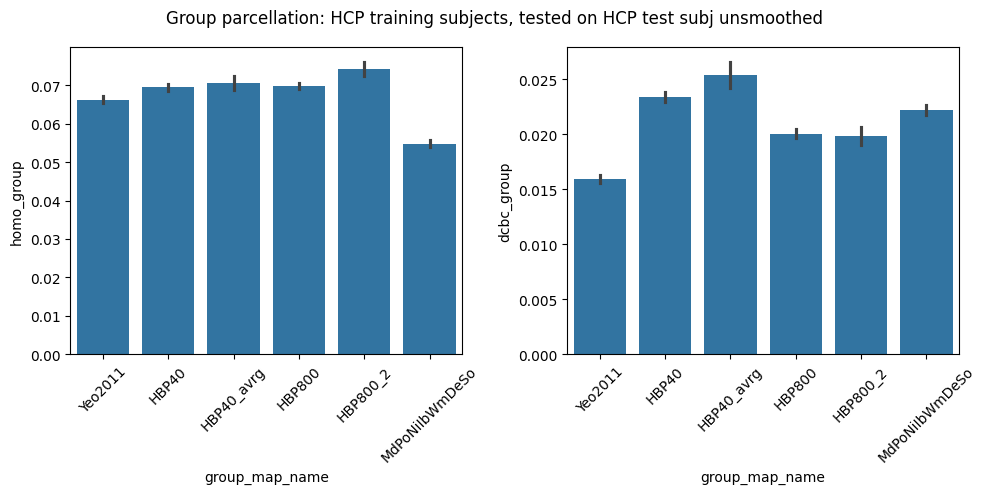

In [12]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-maps_on-HCPtest_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

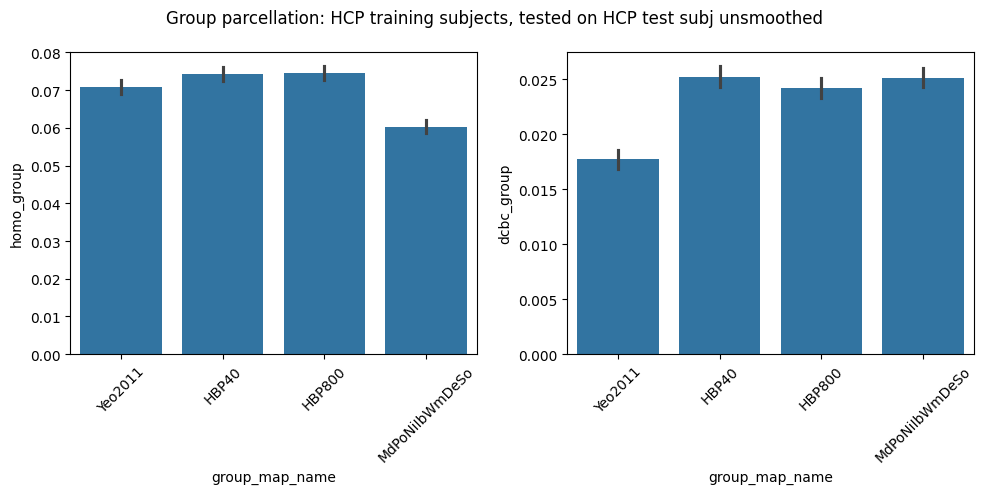

In [3]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-maps_on-HCPtest_split-1.tsv', sep='\t')
    
   
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

0.07428738108999998 0.025212431415000007


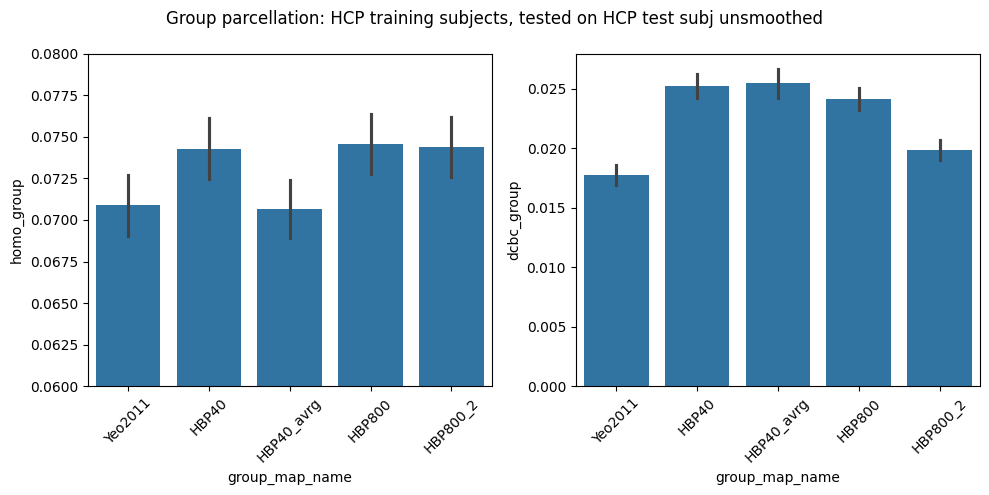

In [20]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-maps_on-HCPtest_split-1.tsv', sep='\t')
to_compare = res.loc[res.group_map_name == 'HBP40']
a = to_compare.homo_group.mean()
b = to_compare.dcbc_group.mean()
print(a,b)
   
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.06, 0.08)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

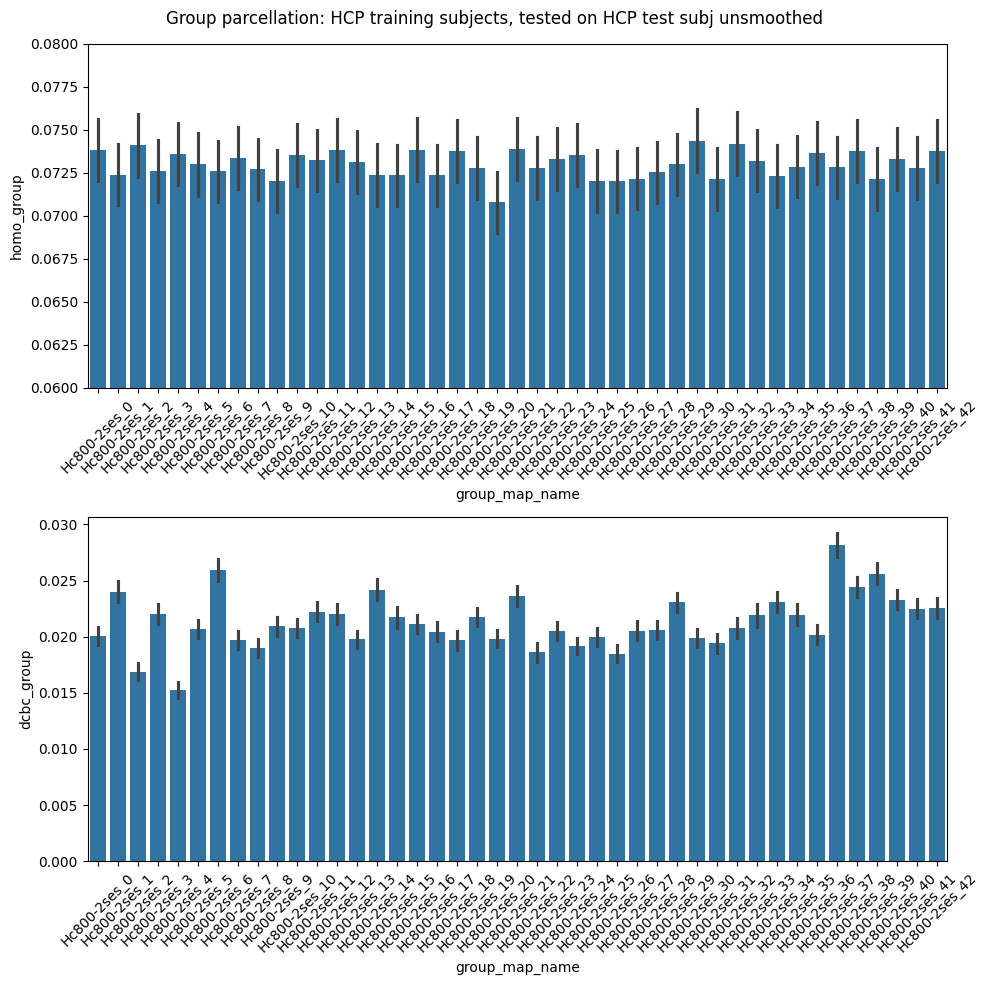

group_map_name
Hc800-2ses_30    0.074364
Name: homo_group, dtype: float64
group_map_name
Hc800-2ses_37    0.028172
Hc800-2ses_39    0.025599
Hc800-2ses_6     0.025966
Name: dcbc_group, dtype: float64


In [19]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HCP800_on-HCPtest_split-1.tsv', sep='\t')
    
   
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.06, 0.08)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

homos = res.groupby('group_map_name')['homo_group'].mean()
homos = homos[homos > a]
print(homos)

dcbcs = res.groupby('group_map_name')['dcbc_group'].mean()
dcbcs = dcbcs[dcbcs > b]
print(dcbcs)

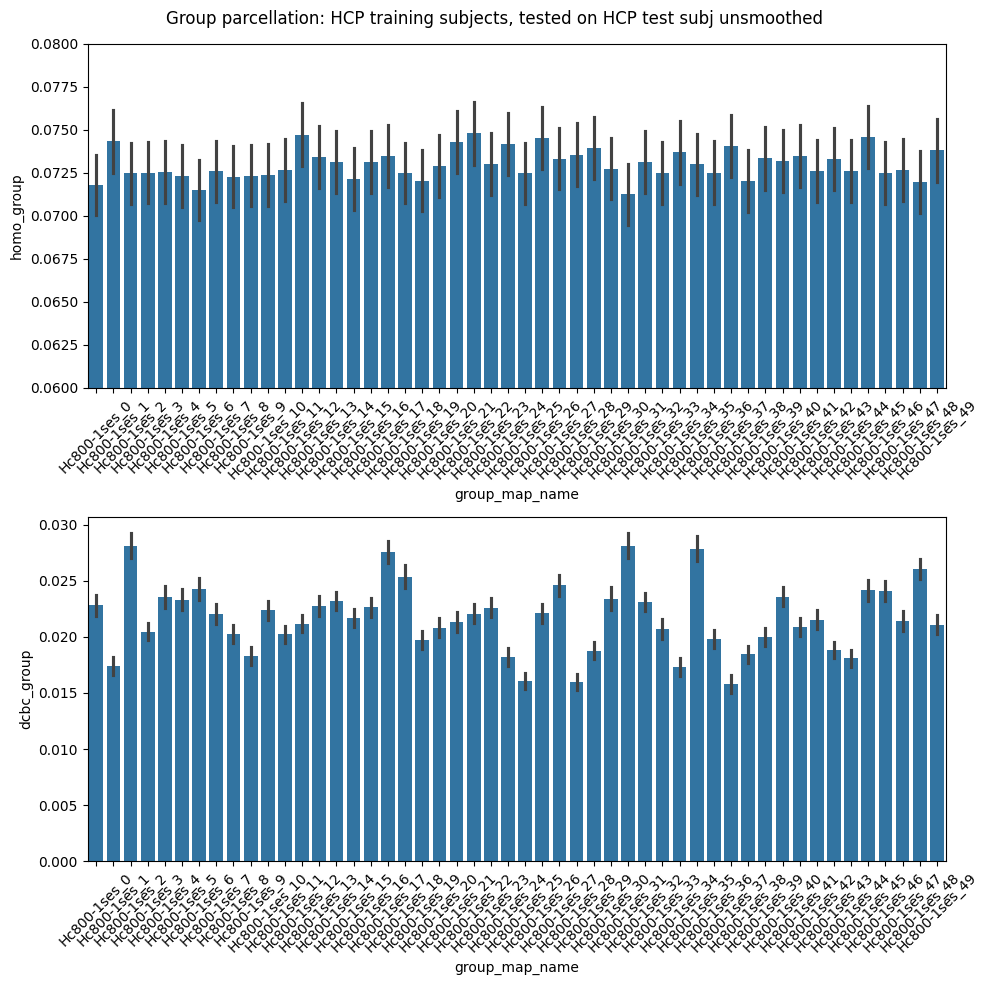

group_map_name
Hc800-1ses_1     0.074324
Hc800-1ses_12    0.074696
Hc800-1ses_21    0.074302
Hc800-1ses_22    0.074792
Hc800-1ses_26    0.074498
Hc800-1ses_45    0.074558
Name: homo_group, dtype: float64
group_map_name
Hc800-1ses_17    0.027573
Hc800-1ses_18    0.025348
Hc800-1ses_2     0.028141
Hc800-1ses_31    0.028143
Hc800-1ses_35    0.027882
Hc800-1ses_48    0.026062
Name: dcbc_group, dtype: float64


In [21]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HCP800-1ses_on-HCPtest_split-1.tsv', sep='\t')
    
   
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.06, 0.08)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

homos = res.groupby('group_map_name')['homo_group'].mean()
homos = homos[homos > a]
print(homos)

dcbcs = res.groupby('group_map_name')['dcbc_group'].mean()
dcbcs = dcbcs[dcbcs > b]
print(dcbcs)

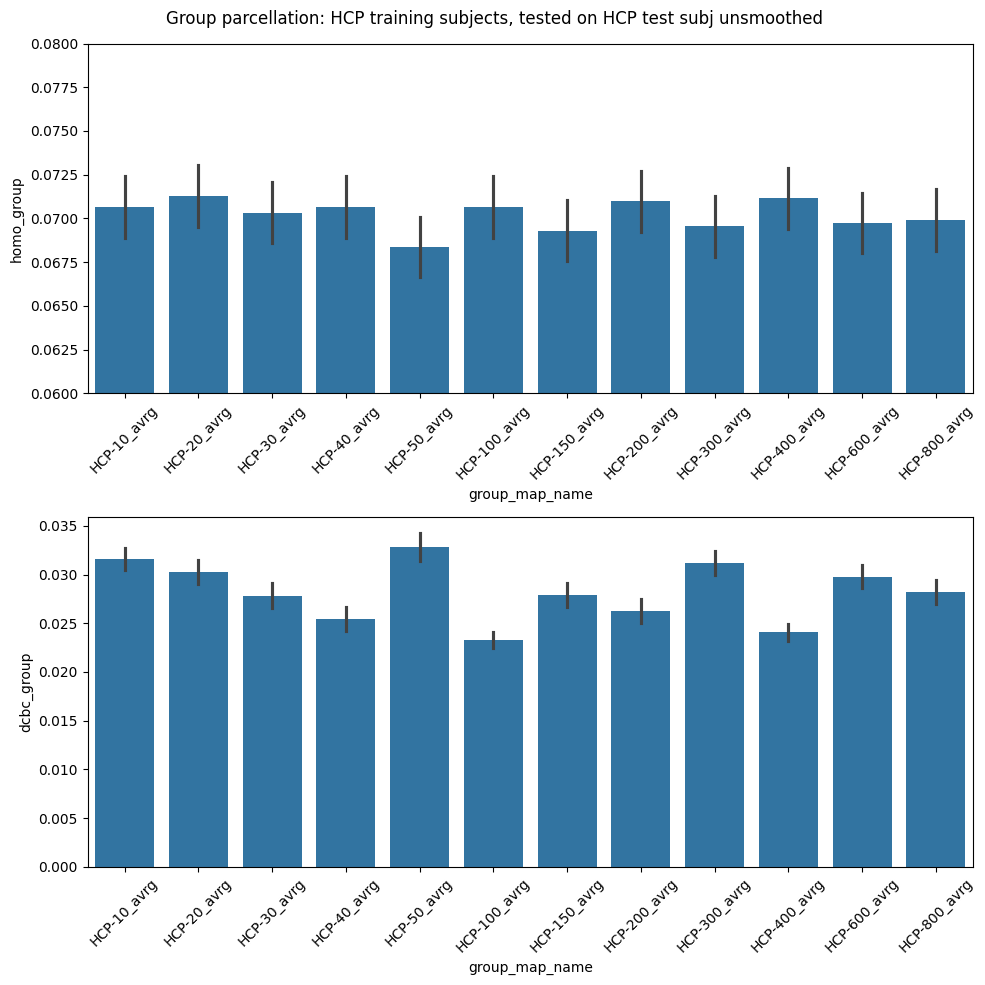

In [22]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HCP10-800-avrg_on-HCPtest_split-1.tsv', sep='\t')

plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.06, 0.08)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Test group parcellations on HCP test data (unsmoothed)

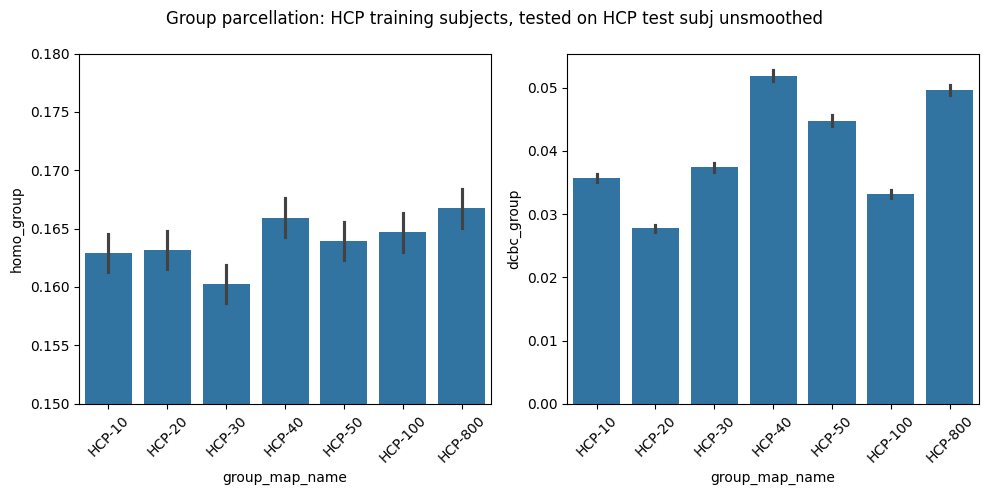

In [11]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HCP10-800_on-HCPtest-sm4fwhm_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.15, 0.18)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Group: HBP vs Existing on HCP 203 test subjects (unsmoothed)

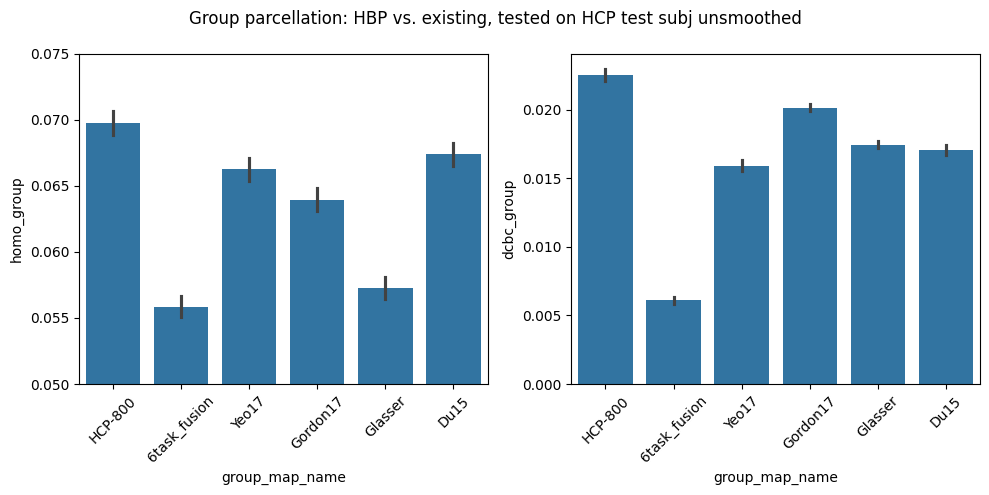

In [37]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-HCPtest_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.05, 0.075)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Group: HBP vs Existing on MDTB 24 test subjects (unsmoothed)

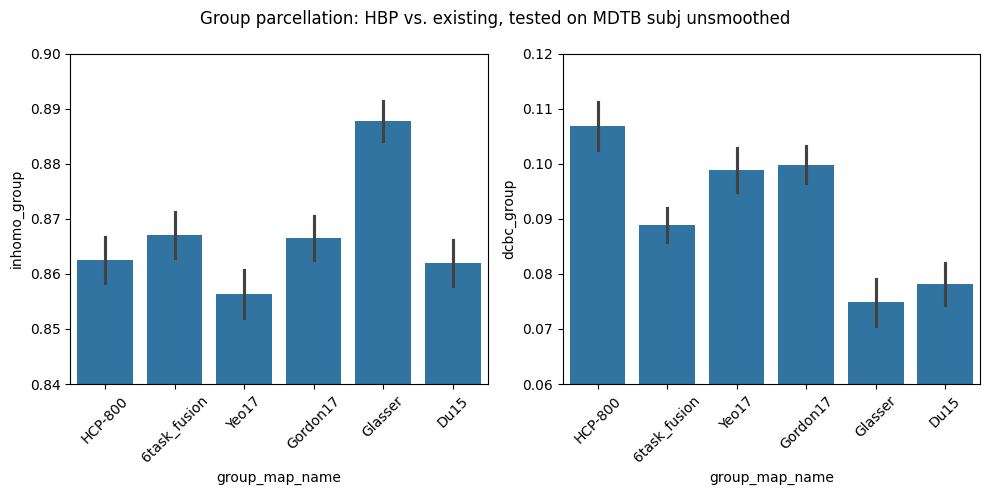

In [24]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-MDTB.tsv', sep='\t')
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', errorbar='se')
plt.ylim(0.84,0.9)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.ylim(0.06, 0.12)
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MDTB subj unsmoothed')
plt.tight_layout()
plt.show()

## Group: Evaluate on MDTB 24 test subjects (unsmoothed, by tasks)

['GoNoGo' 'ToM' 'actionObservation' 'affective' 'arithmetic'
 'checkerBoard' 'emotional' 'intervalTiming' 'motorImagery'
 'motorSequence' 'nBack' 'nBackPic' 'spatialNavigation' 'stroop'
 'verbGeneration' 'visualSearch' 'rest' 'CPRO' 'prediction' 'spatialMap'
 'natureMovie' 'romanceMovie' 'landscapeMovie' 'mentalRotation'
 'emotionProcess' 'respAlt']


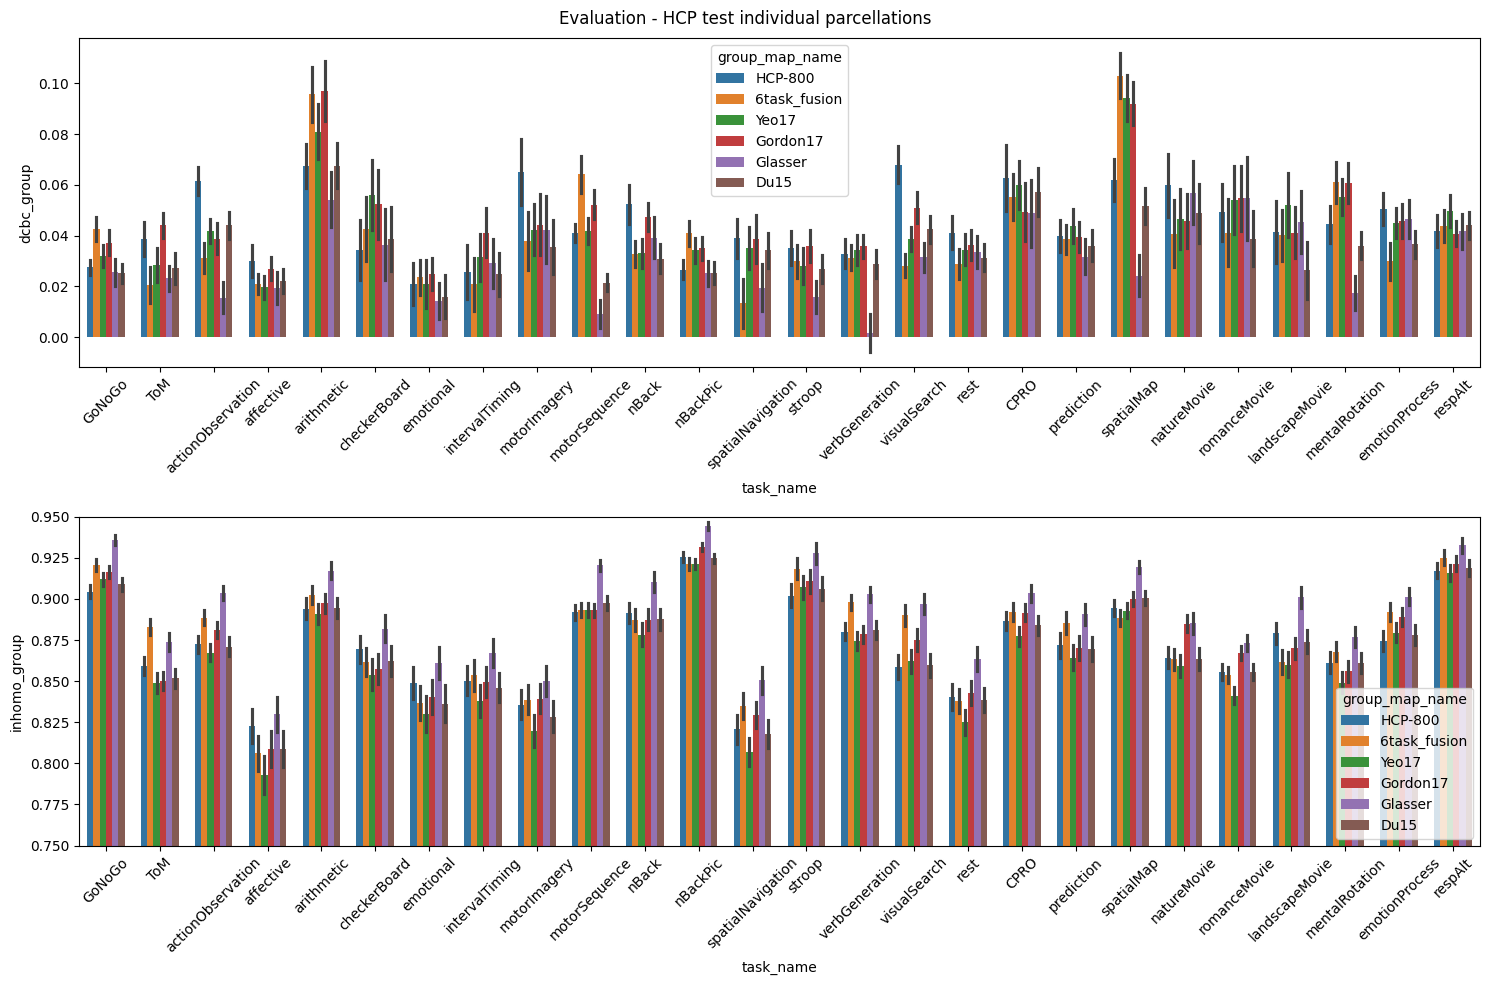

In [7]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.read_csv(RES_DIR + f'/eval_group-HBP_vs_existing_on-MDTB-by-functionaldomains.tsv', sep='\t')
results = results.loc[results['group_map_name'] != '7task_fusion']

print(results.task_name.unique())
# results = results.replace(results.task_name.unique(), ['Executive', 'Social', 'Motor', 'Emotion', 'Numerical', 'Perception',
#                                           'Emotion', 'Temporal', 'Motor', 'Motor', 'Executive', 'Executive', 'Spatial',
#                                           'Executive', 'Language', 'Perception', 'Rest', 'Executive', 'Executive',
#                                           'Spatial', 'Social', 'Social', 'Perception', 'Spatial', 'Emotion', 'Motor'])

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_group', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_group', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.ylim(0.75, 0.95)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()
plt.show()

## Group: HBP vs Existing on HCP test 203 subjects task fMRI (unsmoothed)

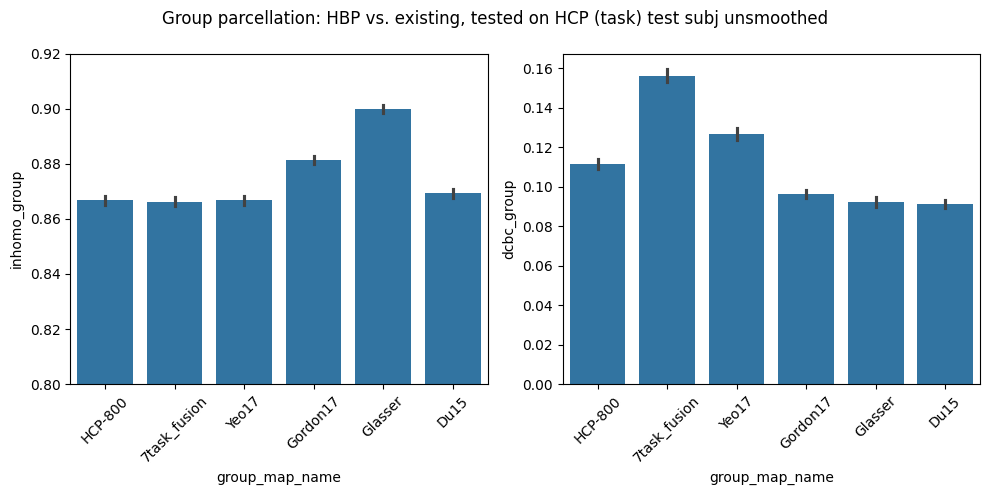

In [9]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-HCPtest-task_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
results = results.loc[results['group_map_name'] != '6task_fusion']
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', errorbar='se')
plt.ylim(0.8, 0.92)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on HCP (task) test subj unsmoothed')
plt.tight_layout()
plt.show()

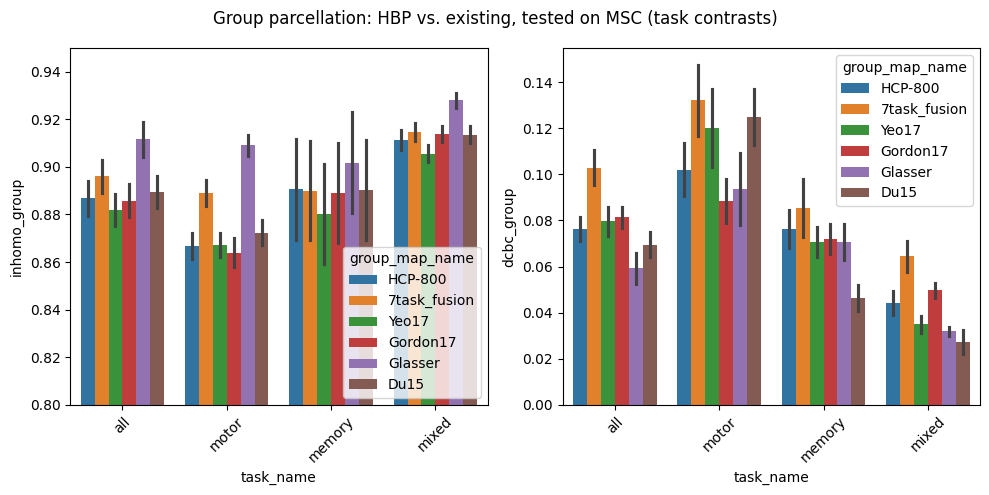

In [7]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-MSC-task-contrasts.tsv', sep='\t')
    
results = results.loc[results['group_map_name'] != '6task_fusion']
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='task_name', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.ylim(0.8, 0.95)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MSC (task contrasts)')
plt.tight_layout()
plt.show()

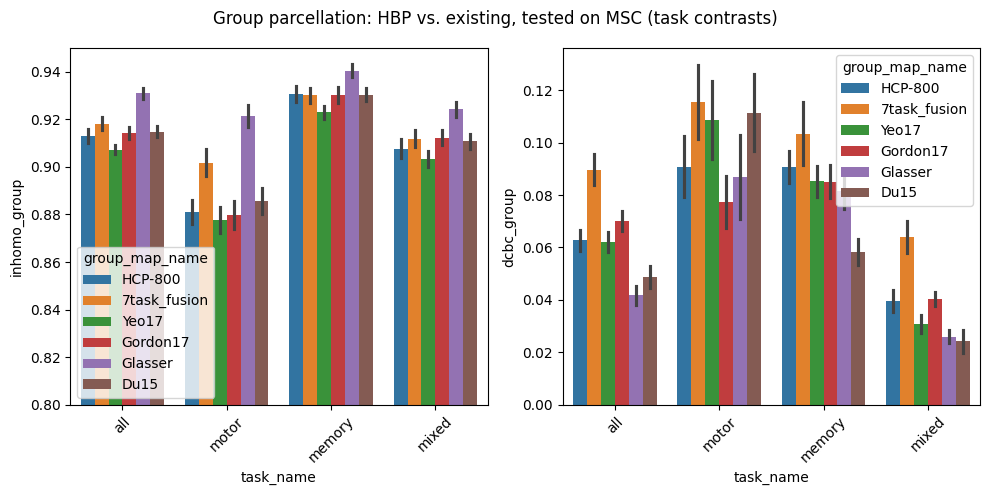

In [4]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-MSC-task-contrasts_2.tsv', sep='\t')
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='task_name', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.ylim(0.8, 0.95)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MSC (task contrasts)')
plt.tight_layout()
plt.show()

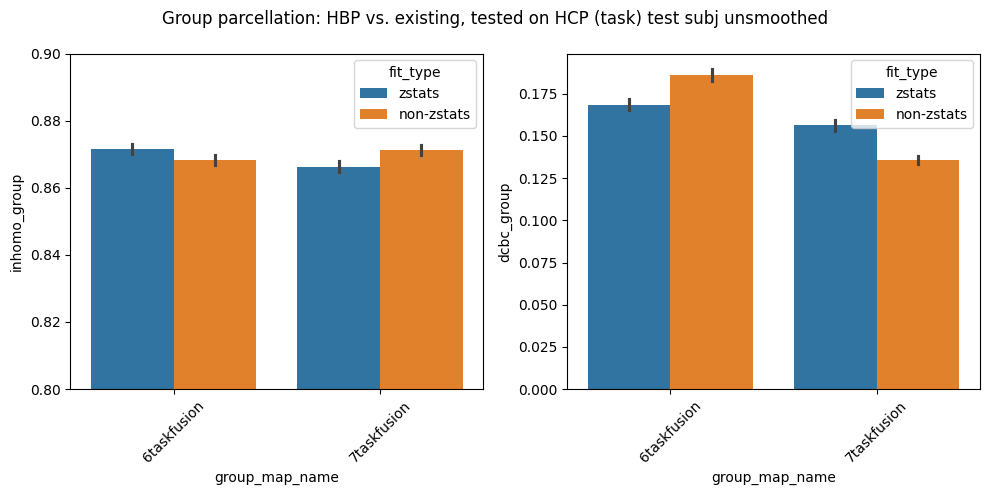

In [36]:
results_new = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-HCPtest-task_split-{i}.tsv', sep='\t')
    results_new = pd.concat([results_new, res], ignore_index=True)

results_new = results_new.replace(['6task_fusion', '7task_fusion'], ['6taskfusion', '7taskfusion'])
results_new['fit_type'] = 'zstats'
results_new = results_new.loc[results_new['group_map_name'].isin(['6taskfusion', '7taskfusion'])]

results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-taskfusion-old_on-HCPtest-task.tsv', sep='\t')
results['fit_type'] = 'non-zstats'

results = pd.concat([results_new, results], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', hue='fit_type', errorbar='se')
plt.ylim(0.8,0.9)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', hue='fit_type', errorbar='se')

plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on HCP (task) test subj unsmoothed')
plt.tight_layout()
plt.show()

## Comparing task fusion group atlas (K=15) by different smoothing (test on HCP 203)

(764, 17) (191, 17)


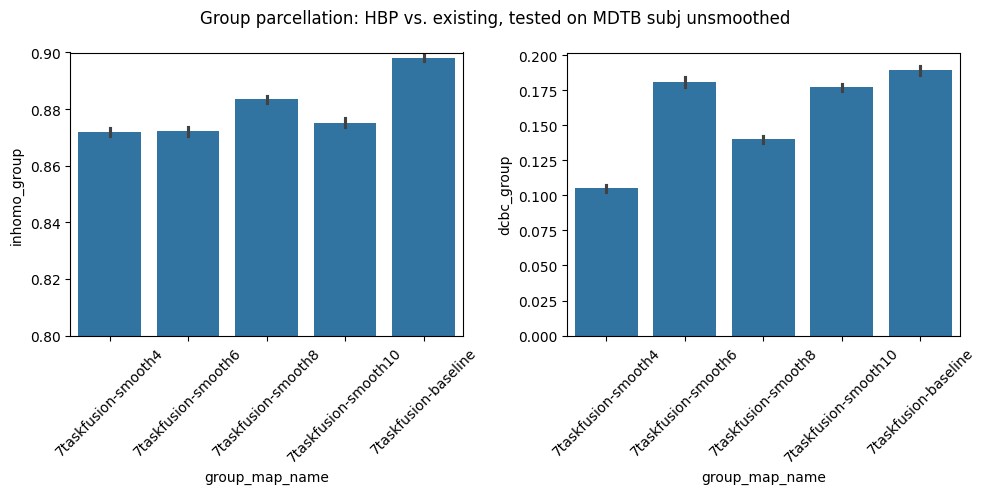

In [6]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_7taskfusion_K-15_sm4-10_on-HCP203test-task.tsv', sep='\t')

print(results1.shape, results2.shape)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', errorbar='se')
plt.ylim(0.8,0.9)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MDTB subj unsmoothed')
plt.tight_layout()
plt.show()

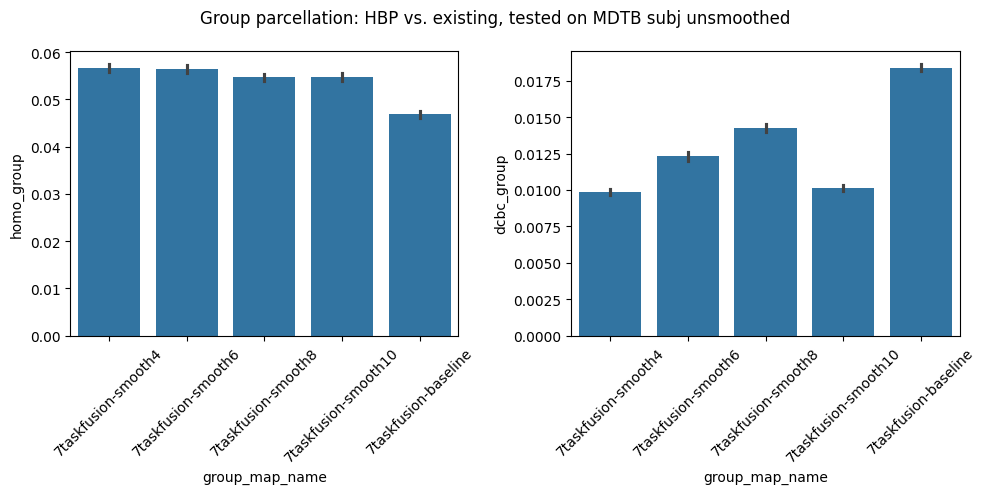

In [11]:
results = pd.DataFrame()
for i in [0,1,2,3]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_7taskfusion_K-15_sm4-10_on-HCP203test-rest-run{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se', 
           order=['7taskfusion-smooth4','7taskfusion-smooth6','7taskfusion-smooth8','7taskfusion-smooth10','7taskfusion-baseline'])

plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se',
          order=['7taskfusion-smooth4','7taskfusion-smooth6','7taskfusion-smooth8','7taskfusion-smooth10','7taskfusion-baseline'])
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MDTB subj unsmoothed')
plt.tight_layout()
plt.show()

## Task fusion group atlas (K=15, 17, 20) baseline vs. smooth vs. smooth+mask (test on HCP 203 task contrasts)

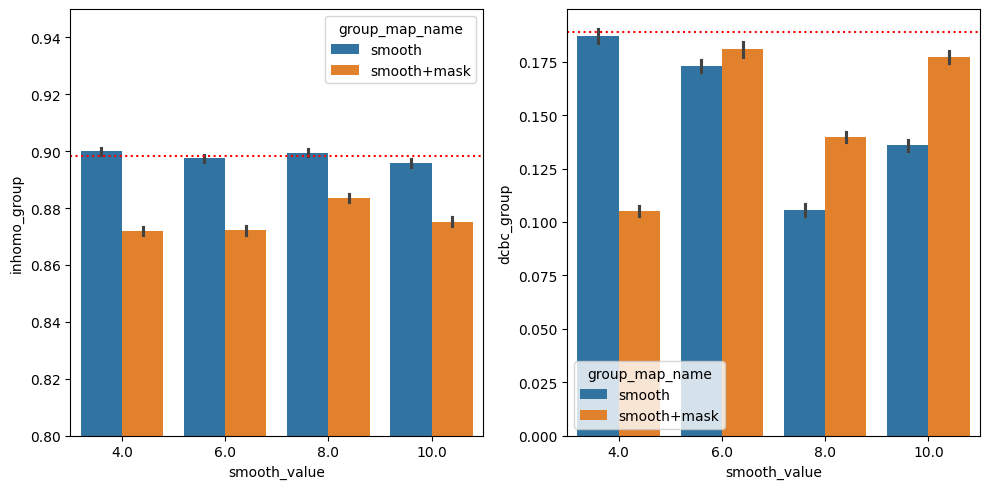

In [9]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-7taskfusion_K-15_sm4-10_on-HCP203test-task.tsv', sep='\t')

to_compare = results.loc[results.group_map_name == 'baseline']
results = results.loc[results.group_map_name != 'baseline']
results['smooth_value'] = results['group_map_name'].str.extract('(\d+)').astype(float)

results = results.replace(['smooth4fwhm', 'smooth6fwhm', 'smooth8fwhm', 'smooth10fwhm'],['smooth','smooth','smooth','smooth'])
results = results.replace(['smooth4fwhm_mask', 'smooth6fwhm_mask', 'smooth8fwhm_mask', 'smooth10fwhm_mask'],
                          ['smooth+mask','smooth+mask','smooth+mask','smooth+mask'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='smooth_value', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.axhline(y=to_compare.inhomo_group.mean(), color='r', linestyle=':')
plt.ylim(0.8, 0.95)

plt.subplot(1,2,2)
sb.barplot(data=results, x='smooth_value', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.tight_layout()
plt.show()

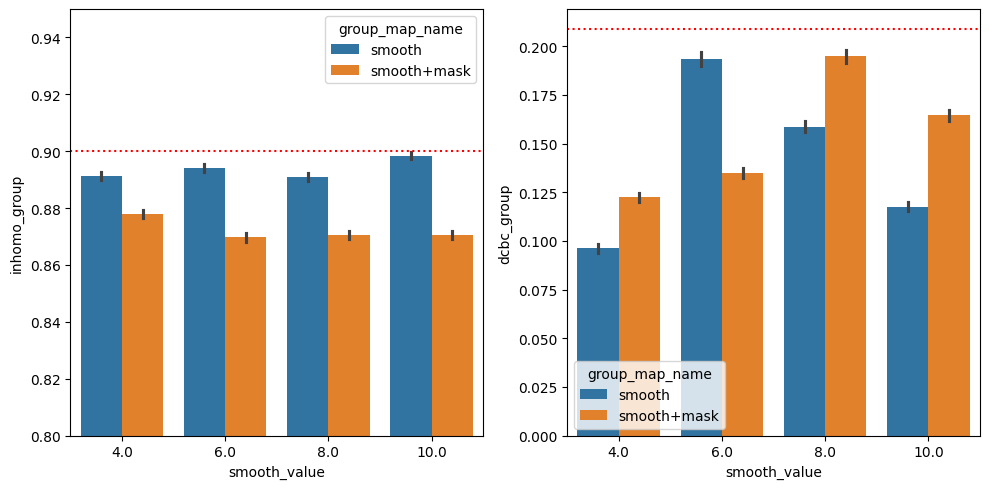

In [8]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-7taskfusion_K-17_sm4-10_on-HCP203test-task.tsv', sep='\t')

to_compare = results.loc[results.group_map_name == 'baseline']
results = results.loc[results.group_map_name != 'baseline']
results['smooth_value'] = results['group_map_name'].str.extract('(\d+)').astype(float)

results = results.replace(['smooth4fwhm', 'smooth6fwhm', 'smooth8fwhm', 'smooth10fwhm'],['smooth','smooth','smooth','smooth'])
results = results.replace(['smooth4fwhm_mask', 'smooth6fwhm_mask', 'smooth8fwhm_mask', 'smooth10fwhm_mask'],
                          ['smooth+mask','smooth+mask','smooth+mask','smooth+mask'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='smooth_value', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.axhline(y=to_compare.inhomo_group.mean(), color='r', linestyle=':')
plt.ylim(0.8, 0.95)

plt.subplot(1,2,2)
sb.barplot(data=results, x='smooth_value', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.tight_layout()
plt.show()

## Task fusion group atlas (K=10-24) baseline vs. smooth+mask (test on HCP 203 task betas)

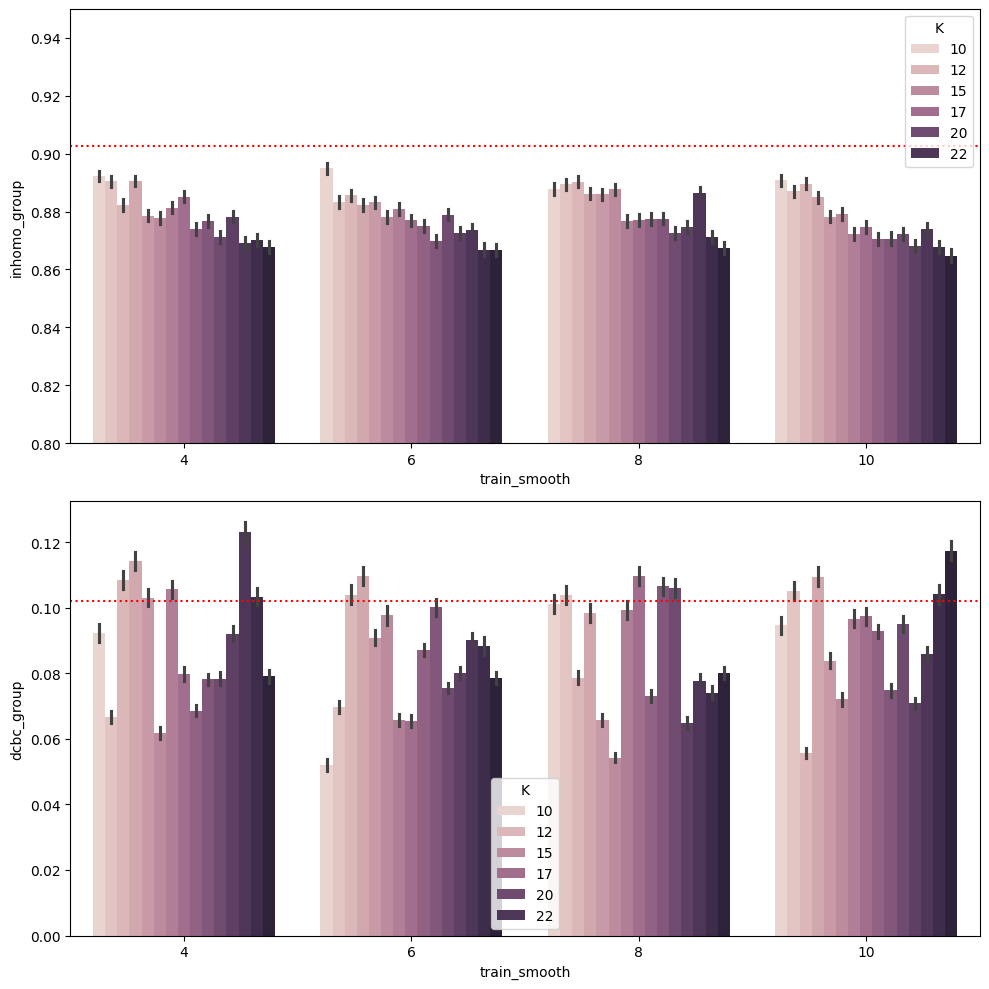

In [9]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-7taskfusion_K-10-24_sm4-10-masked_on-HCP203test-task.tsv', sep='\t')

to_compare = results.loc[results.group_map_name == 'baseline']
results = results.loc[results.group_map_name != 'baseline']
# results['smooth_value'] = results['group_map_name'].str.extract('(\d+)').astype(float)

# results = results.replace(['smooth4fwhm', 'smooth6fwhm', 'smooth8fwhm', 'smooth10fwhm'],['smooth','smooth','smooth','smooth'])
# results = results.replace(['smooth4fwhm_mask', 'smooth6fwhm_mask', 'smooth8fwhm_mask', 'smooth10fwhm_mask'],
#                           ['smooth+mask','smooth+mask','smooth+mask','smooth+mask'])

plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sb.barplot(data=results, x='train_smooth', y='inhomo_group', hue='K', errorbar='se')
# sb.barplot(data=results, x='K', y='inhomo_group', errorbar='se')
plt.axhline(y=to_compare.inhomo_group.mean(), color='r', linestyle=':')
plt.ylim(0.8, 0.95)

plt.subplot(2,1,2)
sb.barplot(data=results, x='train_smooth', y='dcbc_group', hue='K', errorbar='se')
# sb.barplot(data=results, x='K', y='dcbc_group', errorbar='se')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.tight_layout()
plt.show()

## Task fusion group atlas (K=10-24) baseline vs. smooth+mask (test on MSC task contrasts)

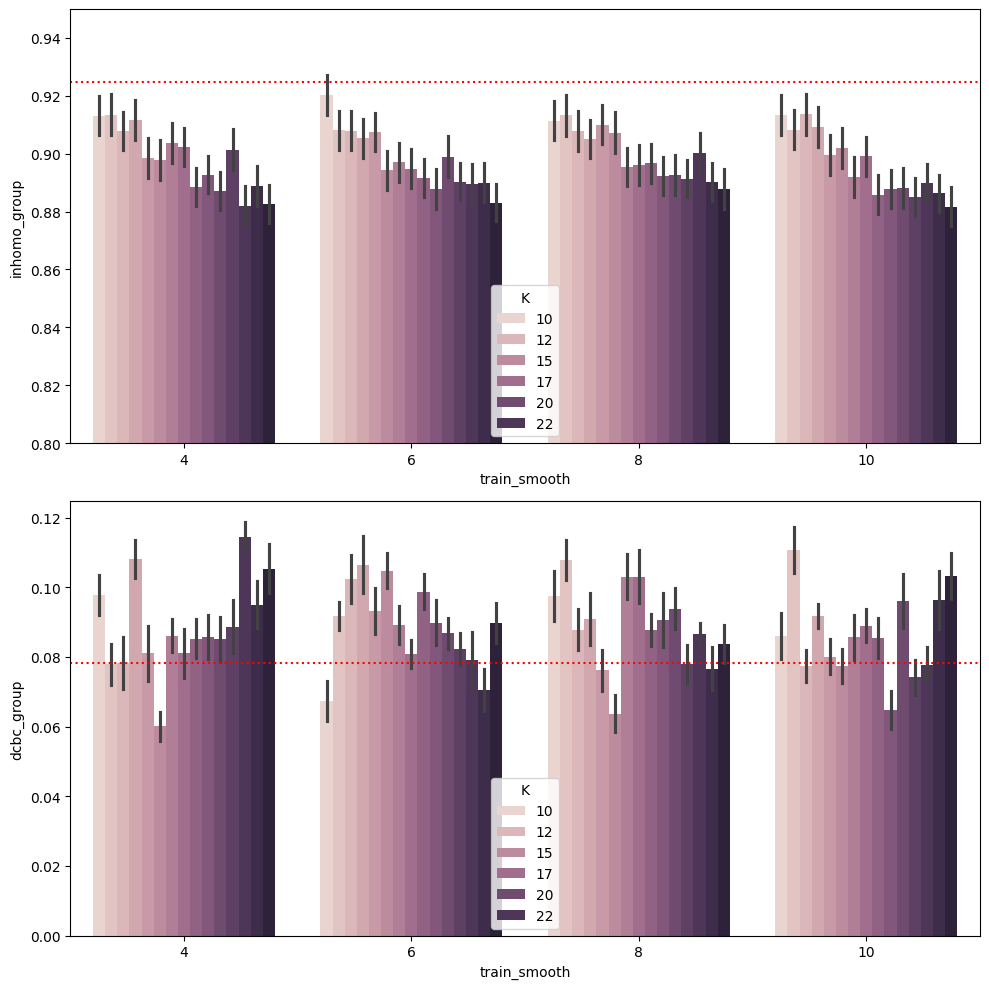

In [3]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-7taskfusion_K-10-25_sm4-10-masked_on-MSC-task-contrasts.tsv', sep='\t')

to_compare = results.loc[results.group_map_name == 'baseline']
results = results.loc[results.group_map_name != 'baseline']

plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sb.barplot(data=results, x='train_smooth', y='inhomo_group', hue='K', errorbar='se')
plt.axhline(y=to_compare.inhomo_group.mean(), color='r', linestyle=':')
plt.ylim(0.8, 0.95)

plt.subplot(2,1,2)
sb.barplot(data=results, x='train_smooth', y='dcbc_group', hue='K', errorbar='se')
plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.tight_layout()
plt.show()

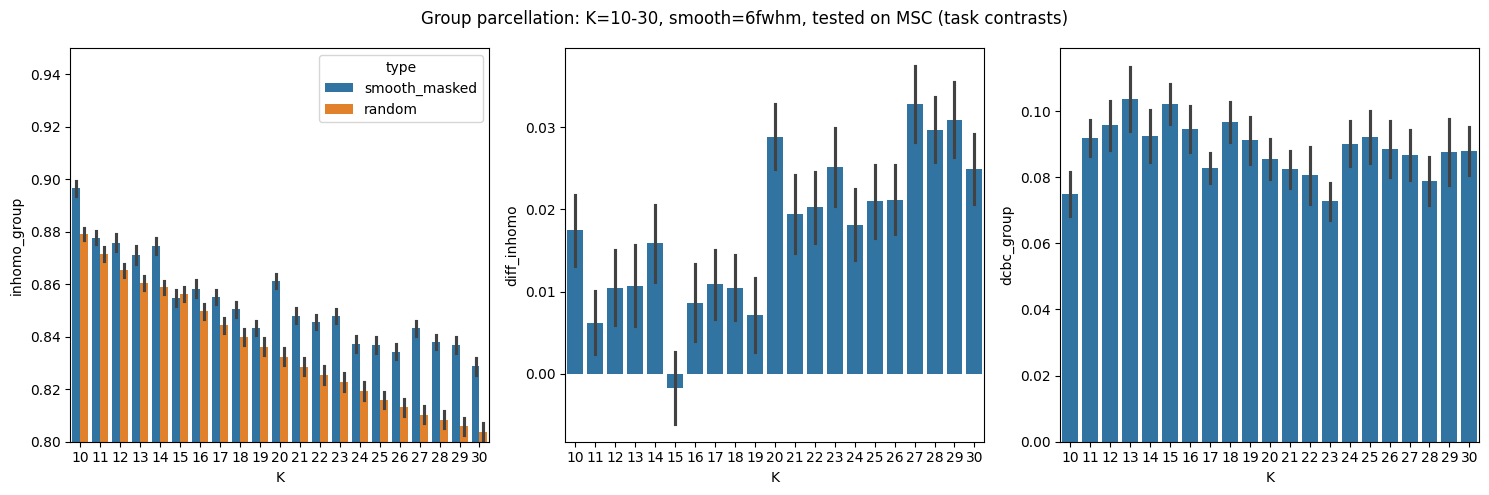

In [5]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-random_K-10-30_sm6-masked_on-MSC-task-contrasts.tsv', sep='\t')
results = results[(results['task_name']=='all')]

res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-fusion_K-10-30_sm8-10-masked_on-MSC-task-contrasts.tsv', sep='\t')

df_random = results[results['group_map_name'].str.startswith('random', na=False)]
df_existing = results[~results['group_map_name'].str.startswith('random', na=False) &
                      ~results['group_map_name'].str.startswith('smooth', na=False)]

df_smooth_masked = results[results['group_map_name'].str.startswith('smooth6', na=False) & (results['task_name']=='all')]
df_random_group_inhomo = df_random.groupby([df_random.K, df_random.subj_num])['inhomo_group'].mean().reset_index()
df_random_group_dcbc = df_random.groupby([df_random.K, df_random.subj_num])['dcbc_group'].mean().reset_index()
df_random_group = df_random_group_inhomo.merge(df_random_group_dcbc, on=['K', 'subj_num'])

df_random_group.loc[:,'type'] = 'random'

df_sm = df_smooth_masked[['K', 'subj_num', 'inhomo_group','dcbc_group']].reset_index(drop=True)
df_sm['type'] = 'smooth_masked'
df_new = pd.concat([df_sm, df_random_group], ignore_index=True)
df_sm['diff_inhomo'] = df_sm['inhomo_group'] - df_random_group['inhomo_group']
df_sm['diff_dcbc'] = df_sm['dcbc_group'] - df_random_group['dcbc_group']

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sb.barplot(data=df_new, x='K', y='inhomo_group', hue='type', errorbar='se')
plt.ylim(0.8, 0.95)
plt.subplot(1, 3, 2)
sb.barplot(data=df_sm, x='K', y='diff_inhomo', errorbar='se')

plt.subplot(1, 3, 3)
sb.barplot(data=df_sm, x='K', y='dcbc_group', errorbar='se')



plt.suptitle('Group parcellation: K=10-30, smooth=6fwhm, tested on MSC (task contrasts)')
plt.tight_layout()
plt.show()